# Exchangeable vs. total Cs137 ratio

> Prediction of exCs137/totalCs137 using Fukushima/J-REI data

In [ ]:
from pathlib import Path
import numpy as np
from fastcore.all import *
from soilspecdl.dataloader import get_fuku_cs137, get_spectral_dls, get_pre_splitter
from soilspecdl.models import cnt_params

In [ ]:
from fastai.vision.all import *
from fastai.callback.hook import ActivationStats
from fastai.learner import Learner
from fastai.callback.schedule import lr_find
from fastai.losses import MSELossFlat
from fastai.metrics import R2Score
from fastai.callback.hook import ActivationStats

## Data loading

In [ ]:
data_fuku = get_fuku_cs137(Path('../../_data/'))
wns = data_fuku['wns']
id_train, X_train, y_train = data_fuku['train'].values()
id_test, X_test, y_test = data_fuku['test'].values()

len(X_train), len(X_test), len(wns)

(1194, 398, 657)

In [ ]:
X_all = np.concatenate([X_train, X_test])
y_all = np.concatenate([y_train, y_test])
splitter = get_pre_splitter(n_train=len(X_train))

In [ ]:
dls, test_idx = get_spectral_dls(X_all, y_all, wns, splitter=get_pre_splitter(n_train=len(X_train)))

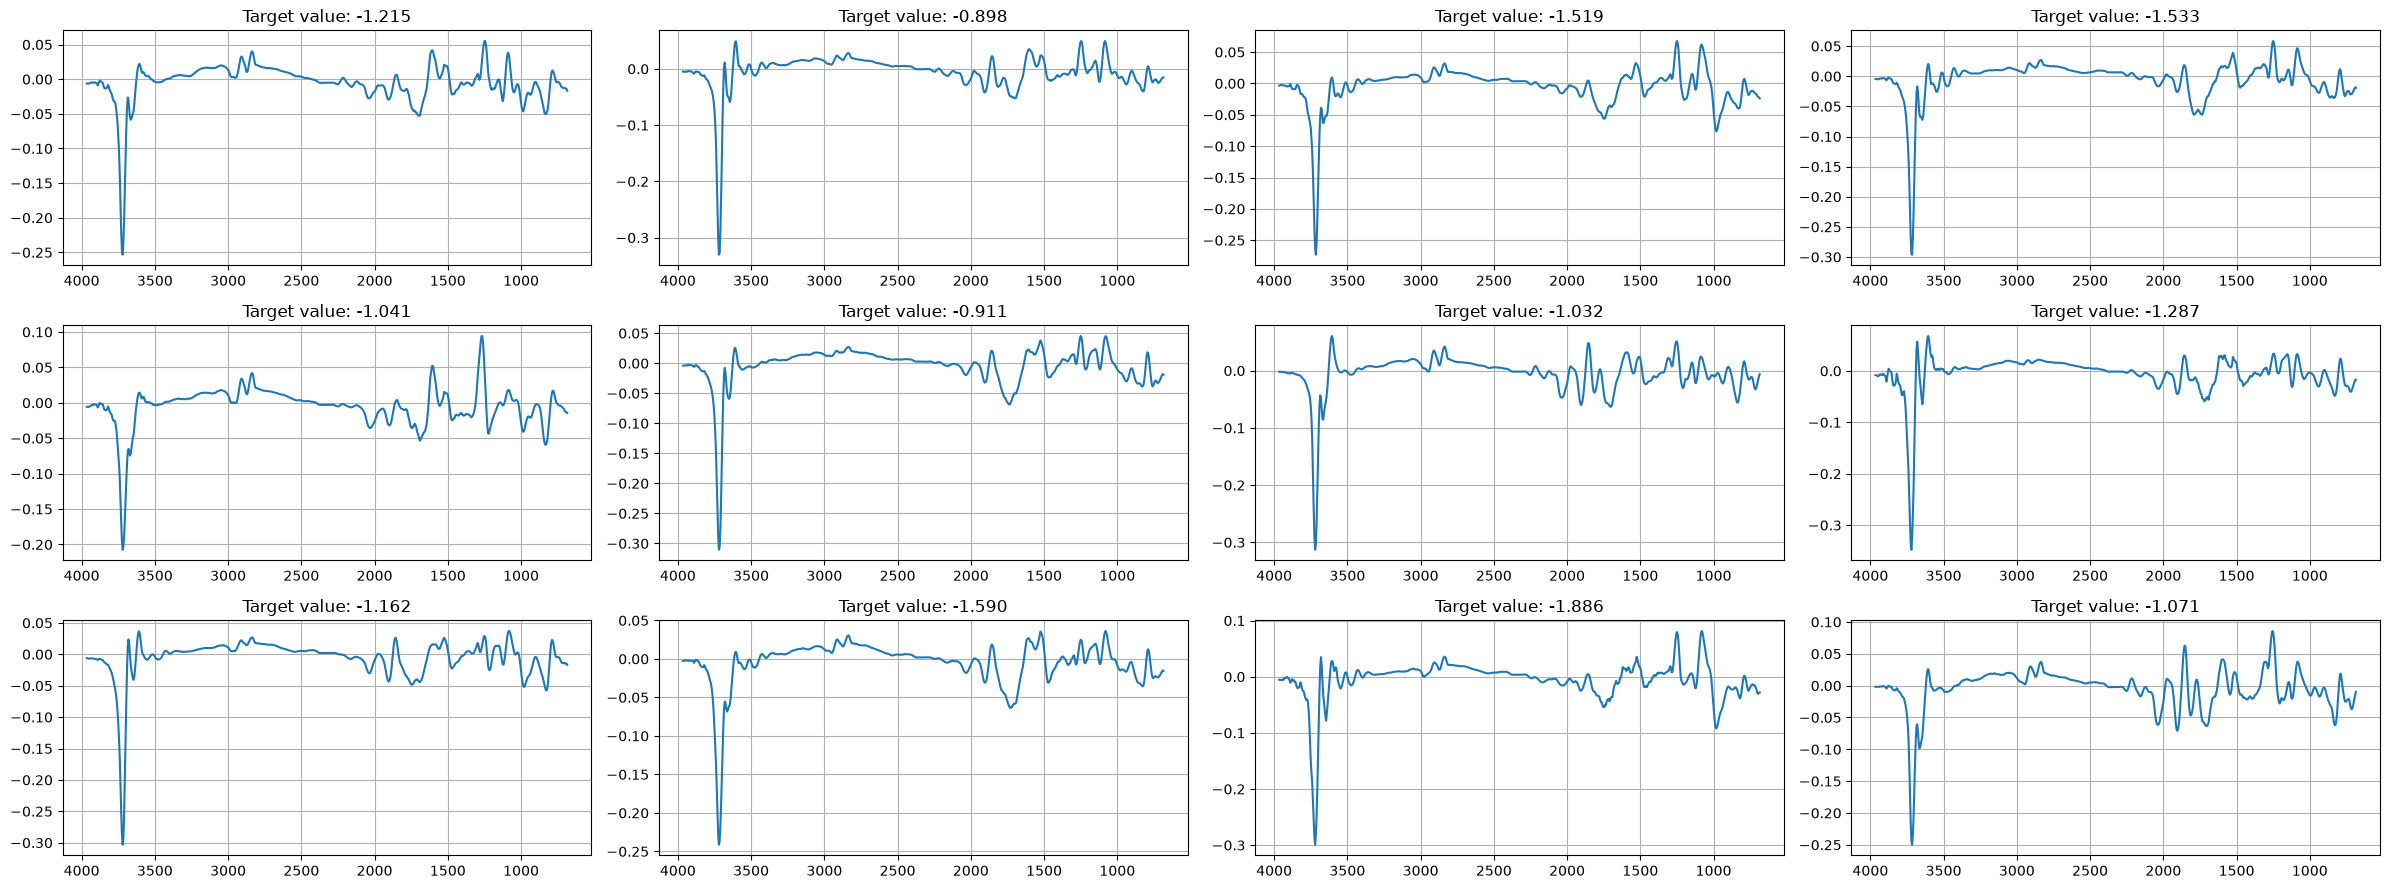

In [ ]:
dls.show_batch(max_n=12, ncols=4)

## Modeling

In [ ]:
!ls ../

00_models.html.md    01_dataloader_files  index.ipynb  nbdev.yml
00_models.ipynb      _quarto.yml	  index_files  site_libs
01_dataloader.ipynb  examples		  models       styles.css


I want to create a CNN architecture for this dataset. Note that the number of wns is 657 (resolution 5) as opposed to the number of wns expected by the MirzaiCNN architecture (1701) in 00_models.ipynb. 

- I'd like to adapt this model, simplify it. We can in particular reduce avgpooling (to 2 for instance), reduce the number of layers in the feature extractor
- but let's build it progressively, checking how the learning goes:
```
from fastai.callback.hook import ActivationStats
act_stats = ActivationStats(with_hist=True)
learn = Learner(dls_fuku, MirzaiCNN(), loss_func=MSELossFlat(), metrics=R2Score(), cbs=act_stats)
learn.fit_one_cycle(10, lr_max=2e-3)
act_stats.plot_layer_stats()
...
```


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Let me first look at the current MirzaiCNN architecture to understand what we're adapting from.



<details class='tool-usage-details' markdown='1'>
<summary><code>load_dialog(src_dname=&quot;/soilspecdl/nbs/00_models&quot;)→&quot;No output&quot;</code></summary>

```json
{
  "id": "call_00_sc2jV4bZbASwOuLR6L7Z5941",
  "server": false,
  "call": {
    "function": "load_dialog",
    "arguments": {
      "src_dname": "/soilspecdl/nbs/00_models"
    }
  },
  "result": "No output"
}
```

</details>







<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;doc(MirzaiCNN)&quot;)→&quot;class MirzaiCNN(Module):\n    \&quot;\&quot;\&quot;1D Convo…&quot;</code></summary>

```json
{
  "id": "call_00_yUCx2tIHwJn7PfDMLOfr6488",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "doc(MirzaiCNN)"
    }
  },
  "result": "class MirzaiCNN(Module):\n    \"\"\"1D Convolutional Neural Network for spectral data regression/classification.\n    \n    Based on the architecture proposed in:\n    Albinet, F., Peng, Y., Eguchi, T., Smolders, E., Dercon, G., 2022. Prediction of exchangeable potassium in soil through mid-infrared spectroscopy and deep learning: From prediction to explainability. Artificial Intelligence in Agriculture 6, 230–241. https://doi.org/10.1016/j.aiia.2022.10.001\"\"\"\n    def __init__(self, in_channel: int = 1, out_channel: int = 16, conv_block_cls: Callable[] = <class '__main__.ConvBlock'>, is_classifier: bool = False, dropout: float = 0.4): ...\n    def forward(self, x): ..."
}
```

</details>









<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;doc(MirzaiCNN.forward)&quot;)→&quot;def forward(\n    x\n):\n\&quot;\&quot;\&quot;Define the comp…&quot;</code></summary>

```json
{
  "id": "call_00_QPQzEqFtiC4a17SyoNcg7267",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "doc(MirzaiCNN.forward)"
    }
  },
  "result": "def forward(\n    x\n):\n\"\"\"Define the computation performed at every call.\n\nShould be overridden by all subclasses.\n\n.. note::\n    Although the recipe for forward pass needs to be defined within\n    this function, one should call the :class:`Module` instance afterwards\n    instead of this since the former takes care of running the\n    registered hooks while the latter silently ignores them.\"\"\""
}
```

</details>



<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;info_md(MirzaiCNN.__init__, source=True)&quot;)→&quot;\n\\`\\`\\`\\`python\ndef __init__(self, \n    …&quot;</code></summary>

```json
{
  "id": "call_01_XI7QtyCQCGMFC75CIT0C9128",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "info_md(MirzaiCNN.__init__, source=True)"
    }
  },
  "result": "\n````python\ndef __init__(self, \n             in_channel: int=1, # input channels\n             out_channel: int=16, # base number of filters\n             conv_block_cls: Callable = ConvBlock,\n             is_classifier: bool=False, # if True, model will output probabilities\n             dropout: float=0.4 # dropout rate\n             ):\n    super().__init__()\n    self.backbone = FeatureExtractor(in_channel, out_channel, conv_block_cls=conv_block_cls)\n    self.head = Sequential(\n        Dropout(dropout), \n        Linear(256, 1))\n    self.is_classifier = is_classifier\n````\n\n**File:** `/tmp/ipymini_64/1348098512.py`; line: 8"
}
```

</details>







<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;doc(FeatureExtractor); print(&#x27;---&#x27;); doc…&quot;)→&quot;---\n\nclass ConvBlock(Module):\n    \&quot;\&quot;\&quot;Con…&quot;</code></summary>

```json
{
  "id": "call_00_74nAZEQ4KAgRRJHtc1Rf0114",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "doc(FeatureExtractor); print('---'); doc(ConvBlock)"
    }
  },
  "result": "---\n\nclass ConvBlock(Module):\n    \"\"\"Convolutional block with pooling.\"\"\"\n    def __init__(self, ni, nf, ks=3, stride=1, pool_sz=3, act_cls=functools.partial(<class 'torch.nn.modules.activation.LeakyReLU'>, negative_slope=0.1)): ...\n    def forward(self, x): ..."
}
```

</details>







<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;info_md(FeatureExtractor.__init__, sourc…&quot;)→&quot;---\n---\n\n\n\\`\\`\\`\\`python\ndef forward(sel…&quot;</code></summary>

```json
{
  "id": "call_00_fwze4cuFSFzyEH4SsF781909",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "info_md(FeatureExtractor.__init__, source=True); print('---'); info_md(ConvBlock.__init__, source=True); print('---'); info_md(ConvBlock.forward, source=True)"
    }
  },
  "result": "---\n---\n\n\n````python\ndef forward(self, x): return self.pool(self.conv(x))\n````\n\n**File:** `/tmp/ipymini_64/2882107428.py`; line: 15"
}
```

</details>







<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;info_md(FeatureExtractor, source=True)&quot;)→&quot;----------------------------------------…&quot;</code></summary>

```json
{
  "id": "call_00_Y5ijM5gOsIWZzno05ivh9057",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "info_md(FeatureExtractor, source=True)"
    }
  },
  "result": "---------------------------------------------------------------------------\nKeyError                                  Traceback (most recent call last)\nCell In[45], line 1\n----> 1 await call_tool(python, {'code': 'info_md(FeatureExtractor, source=True)'})\n\nFile /usr/local/lib/python3.12/site-packages/ipykernel_helper/core.py:373, in call_tool(func, kw)\n    371 async def call_tool(func, kw):\n    372     \"Call `func(**kw)` with `coerce_inputs`\"\n--> 373     return await maybe_await(func(**coerce_inputs(func, kw)))\n\nFile /usr/local/lib/python3.12/site-packages/fastcore/xtras.py:1079, in maybe_await(o)\n   1077 \"Await `o` if needed, and return it\"\n   1078 from inspect import isawaitable\n-> 1079 return await o if isawaitable(o) else o\n\nFile /usr/local/lib/python3.12/site-packages/safepyrun/core.py:299, in RunPython.__call__(self, code)\n    297 tb = e.__traceback__\n    298 while tb.tb_next and not tb.tb_frame.f_code.co_filename.startswith('<python'): tb = tb.tb_next\n--> 299 raise e.with_traceback(tb) from None\n\nFile <python_2>:1\n----> 1 info_md(FeatureExtractor, source=True)\n\nFile /usr/local/lib/python3.12/site-packages/ipykernel_helper/core.py:404, in info_md(obj, source)\n    402 \"With `source=False` same as ipython's `?`, otherwise same as `??`\"\n    403 obj = resolve(obj)\n--> 404 return PrettyString(get_ipython().inspector._get_info(obj, '', detail_level=1 if source else 0)['text/markdown'])\n\nKeyError: 'text/markdown'"
}
```

</details>







<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;doc(FeatureExtractor)&quot;)→&quot;class FeatureExtractor(Module):\n    def …&quot;</code></summary>

```json
{
  "id": "call_00_U2RwvFoj6iCM3Ju0qoGA7721",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "doc(FeatureExtractor)"
    }
  },
  "result": "class FeatureExtractor(Module):\n    def __init__(self, in_channel=1, out_channel=16, n_layers=5, conv_block_cls=<class '__main__.ConvBlock'>): ...\n    def forward(self, x): ..."
}
```

</details>







<details class='tool-usage-details' markdown='1'>
<summary><code>bash(cmd=&quot;grep -n \&quot;class FeatureExtractor\&quot; /tmp/ip…&quot;)→&quot;No output&quot;</code></summary>

```json
{
  "id": "call_00_m4ZjaspKCMg3vgGF11M40947",
  "server": false,
  "call": {
    "function": "bash",
    "arguments": {
      "cmd": "grep -n \"class FeatureExtractor\" /tmp/ipymini_64/*.py 2>/dev/null | head -3"
    }
  },
  "result": "No output"
}
```

</details>







<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;import inspect\nprint(inspect.getfile(Mir…&quot;)→&quot;----------------------------------------…&quot;</code></summary>

```json
{
  "id": "call_00_0WpsOTEsQfqVq3TB5aJb8399",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "import inspect\nprint(inspect.getfile(MirzaiCNN))\nprint(inspect.getsource(FeatureExtractor.__init__))\nprint('---')\nprint(inspect.getsource(FeatureExtractor.forward))"
    }
  },
  "result": "---------------------------------------------------------------------------\nOSError                                   Traceback (most recent call last)\nCell In[48], line 1\n----> 1 await call_tool(python, {'code': \"import inspect\\nprint(inspect.getfile(MirzaiCNN))\\nprint(inspect.getsource(FeatureExtractor.__init__))\\nprint('---')\\nprint(inspect.getsource(FeatureExtractor.forward))\"})\n\nFile /usr/local/lib/python3.12/site-packages/ipykernel_helper/core.py:373, in call_tool(func, kw)\n    371 async def call_tool(func, kw):\n    372     \"Call `func(**kw)` with `coerce_inputs`\"\n--> 373     return await maybe_await(func(**coerce_inputs(func, kw)))\n\nFile /usr/local/lib/python3.12/site-packages/fastcore/xtras.py:1079, in maybe_await(o)\n   1077 \"Await `o` if needed, and return it\"\n   1078 from inspect import isawaitable\n-> 1079 return await o if isawaitable(o) else o\n\nFile /usr/local/lib/python3.12/site-packages/safepyrun/core.py:299, in RunPython.__call__(self, code)\n    297 tb = e.__traceback__\n    298 while tb.tb_next and not tb.tb_frame.f_code.co_filename.startswith('<python'): tb = tb.tb_next\n--> 299 raise e.with_traceback(tb) from None\n\nFile <python_4>:2\n      1 import inspect\n----> 2 print(inspect.getfile(MirzaiCNN))\n      3 print(inspect.getsource(FeatureExtractor.__init__))\n      4 print('---')\n\nFile /usr/local/lib/python3.12/site-packages/torch/package/package_importer.py:745, in _patched_getfile(object)\n    743     if object.__module__ in _package_imported_modules:\n    744         return _package_imported_modules[object.__module__].__file__\n--> 745 return _orig_getfile(object)\n\nFile /usr/local/lib/python3.12/site-packages/ipykernel_helper/core.py:417, in _getfile(obj)\n    416 @patch_to(inspect, nm=\"getfile\")\n--> 417 def _getfile(obj): return str(inspect._orig_getfile(obj))\n\nFile /usr/local/lib/python3.12/inspect.py:923, in getfile(object)\n    921             return module.__file__\n    922         if object.__module__ == '__main__':\n--> 923             raise OSError('source code not available')\n    924     raise TypeError('{!r} is a built-in class'.format(object))\n    925 if ismethod(object):\n\nOSError: source code not available"
}
```

</details>







<details class='tool-usage-details' markdown='1'>
<summary><code>bash(cmd=&quot;find /app/data/soilspecdl -name \&quot;*.py\&quot; |…&quot;)→&quot;/app/data/soilspecdl/soilspecdl/_modidx.…&quot;</code></summary>

```json
{
  "id": "call_00_v7TeMVnMdsuXvXS7O83a1693",
  "server": false,
  "call": {
    "function": "bash",
    "arguments": {
      "cmd": "find /app/data/soilspecdl -name \"*.py\" | xargs grep -l \"FeatureExtractor\\|ConvBlock\" 2>/dev/null"
    }
  },
  "result": "/app/data/soilspecdl/soilspecdl/_modidx.py\n/app/data/soilspecdl/soilspecdl/models.py"
}
```

</details>





<details class='tool-usage-details' markdown='1'>
<summary><code>bash(cmd=&quot;grep -n -A 50 \&quot;class FeatureExtractor\&quot; /…&quot;)→&quot;51:class FeatureExtractor(Module):\n52-  …&quot;</code></summary>

```json
{
  "id": "call_00_ET_gUCRgQxLKqYjWS10nqxQ4666",
  "server": false,
  "call": {
    "function": "bash",
    "arguments": {
      "cmd": "grep -n -A 50 \"class FeatureExtractor\" /app/data/soilspecdl/soilspecdl/models.py"
    }
  },
  "result": "51:class FeatureExtractor(Module):\n52-    def __init__(self, \n53-                 in_channel=1, # input channels\n54-                 out_channel=16, # base number of filters\n55-                 n_layers=5, # number of conv blocks\n56-                 conv_block_cls=ConvBlock,\n57-                 ):\n58-        super().__init__()\n59-        nfs = [out_channel * 2**i for i in range(n_layers)]\n60-        self.layers = Sequential(*[\n61-            conv_block_cls(ni=in_channel if i==0 else nfs[i-1], nf=nfs[i]) \n62-            for i in range(len(nfs))\n63-        ])\n64-        self.adaptive_pool = AdaptiveAvgPool1d(1)\n65-    \n66-    def forward(self, x): return self.adaptive_pool(self.layers(x))\n67-\n68-# %% ../nbs/00_models.ipynb #f49cdcea\n69-class MirzaiCNN(Module):\n70-    \"\"\"\n71-    1D Convolutional Neural Network for spectral data regression/classification.\n72-    \n73-    Based on the architecture proposed in:\n74-    Albinet, F., Peng, Y., Eguchi, T., Smolders, E., Dercon, G., 2022. Prediction of exchangeable potassium in soil through mid-infrared spectroscopy and deep learning: From prediction to explainability. Artificial Intelligence in Agriculture 6, 230–241. https://doi.org/10.1016/j.aiia.2022.10.001\n75-    \"\"\"\n76-    def __init__(self, \n77-                 in_channel: int=1, # input channels\n78-                 out_channel: int=16, # base number of filters\n79-                 conv_block_cls: Callable = ConvBlock,\n80-                 is_classifier: bool=False, # if True, model will output probabilities\n81-                 dropout: float=0.4 # dropout rate\n82-                 ):\n83-        super().__init__()\n84-        self.backbone = FeatureExtractor(in_channel, out_channel, conv_block_cls=conv_block_cls)\n85-        self.head = Sequential(\n86-            Dropout(dropout), \n87-            Linear(256, 1))\n88-        self.is_classifier = is_classifier\n89-        \n90-    def forward(self, x):\n91-        x = self.backbone(x)\n92-        x = x.squeeze(-1)\n93-        x = self.head(x)\n94-        x = x.squeeze(-1)\n95-        return torch.sigmoid(x) if self.is_classifier else x\n96-\n97-# %% ../nbs/00_models.ipynb #86f4147b\n98-def cnt_params(model):\n99-    for name, param in model.named_parameters():\n100-        print(f\"{name}: {param.numel():,} parameters\")\n101-    print(f\"\\nTotal: {sum(p.numel() for p in model.parameters()):,} parameters\")"
}
```

</details>







<details class='tool-usage-details' markdown='1'>
<summary><code>bash(cmd=&quot;grep -n -B 5 -A 20 \&quot;class ConvBlock\&quot; /ap…&quot;)→&quot;16-\n17-from fastai.layers import ConvLay…&quot;</code></summary>

```json
{
  "id": "call_00_7yK4vj981xDkop4BJ47a5331",
  "server": false,
  "call": {
    "function": "bash",
    "arguments": {
      "cmd": "grep -n -B 5 -A 20 \"class ConvBlock\" /app/data/soilspecdl/soilspecdl/models.py"
    }
  },
  "result": "16-\n17-from fastai.layers import ConvLayer\n18-from typing import Callable\n19-\n20-# %% ../nbs/00_models.ipynb #d77ba715\n21:class ConvBlockBaseline(Module):    \n22-    def __init__(self, ni, nf):\n23-        super().__init__()\n24-        self.conv = Sequential(\n25-            torch.nn.Conv1d(ni, nf, kernel_size=3, stride=1, padding=1, bias=False),\n26-            torch.nn.BatchNorm1d(nf),\n27-            torch.nn.LeakyReLU(negative_slope=0.1)\n28-        )\n29-        self.pool = torch.nn.AvgPool1d(3)\n30-    \n31-    def forward(self, x): return self.pool(self.conv(x))\n32-\n33-# %% ../nbs/00_models.ipynb #654a2525\n34:class ConvBlock(Module):    \n35-    \"Convolutional block with pooling.\"\n36-    def __init__(self, \n37-                 ni, # input channels\n38-                 nf, # output channels\n39-                 ks=3, # kernel size\n40-                 stride=1, # stride\n41-                 pool_sz=3, # pooling kernel size\n42-                 act_cls=partial(LeakyReLU, negative_slope=0.1) # activation\n43-                 ):\n44-        super().__init__()\n45-        self.conv = ConvLayer(ni, nf, ks=ks, stride=stride, bias=False, act_cls=act_cls, ndim=1)\n46-        self.pool = AvgPool1d(pool_sz)\n47-    \n48-    def forward(self, x): return self.pool(self.conv(x))\n49-\n50-# %% ../nbs/00_models.ipynb #ead64c03\n51-class FeatureExtractor(Module):\n52-    def __init__(self, \n53-                 in_channel=1, # input channels\n54-                 out_channel=16, # base number of filters"
}
```

</details>





Here's the full picture of the current MirzaiCNN:

**FeatureExtractor**: 5 `ConvBlock` layers, each with `ConvLayer(1d)` + `AvgPool1d(3)`. Filter sizes double: 16 → 32 → 64 → 128 → 256. Then `AdaptiveAvgPool1d(1)` squeezes the spatial dim to 1.

**Head**: `Dropout(0.4)` → `Linear(256, 1)`.

For 1701 input wavelengths, 5× pool-3 reduces to 7 spatial positions before the adaptive pool. With our 657 inputs, that's only ~2.7 positions — and the adaptive pool saves it, but the early layers are working with a much smaller receptive field ratio.

Let me propose a **2-layer** starting point, pool size 2:

```python
class SimpleCNN(Module):
    def __init__(self, nf=16, pool_sz=2, dropout=0.4):
        store_attr()
        self.features = Sequential(
            ConvBlock(1, nf, pool_sz=pool_sz),
            ConvBlock(nf, nf*2, pool_sz=pool_sz),
            AdaptiveAvgPool1d(1))
        self.head = Sequential(Dropout(dropout), Linear(nf*2, 1))

    def forward(self, x):
        x = self.features(x).squeeze(-1)
        return self.head(x).squeeze(-1)
```

This gives:
- Input 657 → pool(2)×2 → ~164 positions before adaptive pool → **32 features** into the head
- Much simpler gradient flow, fewer params to tune
- We can add layers or increase `nf` once we see how training goes

Want me to show how to instantiate the Learner and train it with activation stats?

<details class='token-usage-details' markdown='1'><summary>$0.0113</summary>

`total=455,127 | in=452,822 | out=2,305 | cached=99.1% | reasoning=1,070 | $0.0113 | deepseek-v4-flash`

</details>


In [ ]:
class SimpleCNN(Module):
    def __init__(self, nf=16, pool_sz=2, dropout=0.4):
        store_attr()
        self.features = Sequential(
            ConvBlock(1, nf, pool_sz=pool_sz),
            ConvBlock(nf, nf*2, pool_sz=pool_sz),
            AdaptiveAvgPool1d(1))
        self.head = Sequential(Dropout(dropout), Linear(nf*2, 1))

    def forward(self, x):
        x = self.features(x).squeeze(-1)
        return self.head(x).squeeze(-1)

In [ ]:
learn = Learner(dls, SimpleCNN(), loss_func=MSELossFlat(), metrics=R2Score())

In [ ]:
learn.model

SimpleCNN(
  (features): Sequential(
    (0): ConvBlock(
      (conv): ConvLayer(
        (0): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
        (1): InstanceNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=False)
        (2): ReLU()
      )
      (pool): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
    )
    (1): ConvBlock(
      (conv): ConvLayer(
        (0): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
        (1): InstanceNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=False)
        (2): ReLU()
      )
      (pool): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
    )
    (2): AdaptiveAvgPool1d(output_size=1)
  )
  (head): Sequential(
    (0): Dropout(p=0.4, inplace=False)
    (1): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [ ]:
#cnt_params(learn.model)

NameError: name 'learn' is not defined

Can you explain each weights calculation? For instance for the first conv layer I think the 48 params comes from the kernel * 16 (without bias) then the 16 additional weights and bias from the batch norm?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Exactly right. Breaking each down:

**`features.0.conv.0.weight` — 48 params**
`Conv1d(1, 16, ks=3, bias=False)` → weight shape `(16, 1, 3)` = 48. No bias term since `bias=False`.

**`features.0.conv.1.weight` + `.bias` — 16 + 16 = 32 params**
`BatchNorm1d(16)` learns a scale (γ) and shift (β) per channel, so 16 each.

**`features.1.conv.0.weight` — 1,536 params**
`Conv1d(16, 32, ks=3, bias=False)` → weight shape `(32, 16, 3)` = 32×16×3 = 1,536.

**`features.1.conv.1.weight` + `.bias` — 32 + 32 = 64 params**
`BatchNorm1d(32)` → γ and β, 32 each.

**`head.1.weight` + `.bias` — 32 + 1 = 33 params**
`Linear(32, 1)` → weight `(1, 32)` = 32, bias = 1.

The 1,713 total is dominated by the second conv layer (1,536), since it connects 16 input channels to 32 output channels with a kernel of 3. That cross-channel mixing is where most of the capacity comes from.

<details class='token-usage-details' markdown='1'><summary>$0.0023</summary>

`total=38,859 | in=38,093 | out=766 | cached=83.3% | reasoning=441 | $0.0023 | deepseek-v4-flash`

</details>


Let's dig further! What's the dimension of the feature maps after the first conv layer?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;x = torch.randn(2, 1, 657)\nx = learn.mod…&quot;)→&quot;PermissionError: Audit: fastaudit.call b…&quot;</code></summary>

```json
{
  "id": "call_00_zkNvWRPGBXhCGjfyNHef9610",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "x = torch.randn(2, 1, 657)\nx = learn.model.features[0](x)\nx.shape"
    }
  },
  "result": "PermissionError: Audit: fastaudit.call blocked in sandbox with args: ('<python>.<module>', 'torch._VariableFunctionsClass.randn')\nCall chain: runpy._run_module_as_main -> runpy._run_code -> __main__.<module> -> __main__.main -> __main__._run_kernel_from_cli -> ipymini.kernel.run_kernel -> ipymini.kernel.MiniKernel.start -> ipymini.kernel.Subshell.run_main -> ipymini.kernel.Subshell._run_loop_body -> asyncio.runners.Runner.run -> asyncio.base_events.BaseEventLoop.run_until_complete -> asyncio.base_events.BaseEventLoop.run_forever -> asyncio.base_events.BaseEventLoop._run_once -> asyncio.events.Handle._run -> microio._task.TaskGroup._run -> microio._task.TaskGroup._call_started -> microio._actor.ActorCore._handle_release -> ipymini.kernel.Subshell._handle_actor_item -> ipymini.kernel.Subshell._handle_message -> ipymini.kernel.Subshell._handle_execute -> ipymini.shell.shell.MiniShell.execute -> ipymini.shell.shell.MiniShell._run_cell -> IPython.core.interactiveshell.InteractiveShell.run_cell_async -> IPython.core.interactiveshell.InteractiveShell.run_ast_nodes -> IPython.core.interactiveshell.InteractiveShell.run_code -> __main__.<module> -> ipykernel_helper.core.call_tool -> fastcore.xtras.maybe_await -> safepyrun.core.RunPython.__call__ -> safepyrun.core._run_python -> safepyrun.core.__run_python -> safepyrun.core.__run_python.<locals>.run -> <python>.<module> -> torch._VariableFunctionsClass.randn. Code message has been added to dialog. Ask user to run it."
}
```

</details>





Ah, the sandbox blocked `torch.randn` — but I can trace the shapes analytically:

**After ConvBlock 1:**
- `Conv1d(1, 16, ks=3, pad=1)` keeps spatial dim: `(B, 16, 657)`
- `AvgPool1d(2)` halves it: `(B, 16, 328)`  (⌊(657−2)/2⌋ + 1)

**After ConvBlock 2:**
- `Conv1d(16, 32, ks=3, pad=1)`: `(B, 32, 328)`
- `AvgPool1d(2)`: `(B, 32, 164)`

**After `AdaptiveAvgPool1d(1)`**: `(B, 32, 1)` → squeeze → the head sees 32 features.

The first conv layer gives you 16 parallel 1d feature maps, each 328 elements long after pooling. Each of those 16 filters is detecting spectral patterns across the wavelength window with its 3-wide kernel sliding along those 328 positions.

<details class='token-usage-details' markdown='1'><summary>$0.0056</summary>

`total=77,412 | in=76,528 | out=884 | cached=75.3% | reasoning=570 | $0.0056 | deepseek-v4-flash`

</details>


In [ ]:
#x = torch.randn(2, 1, 657)
#x = learn.model.features[0](x)
#x.shape

NameError: name 'learn' is not defined

Out of the the first conv1d, I am getting a tensor of size 16x657 right ("a rectangle of height 16 and width 657")? What is batchnorm normalizeing on this rectangle?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Right — for a single sample you get a `(16, 657)` "rectangle". But BN actually looks at the full batch `(B, 16, 657)` and normalizes **per channel** across the remaining axes:

For each channel `c` (0..15), it computes one μ_c and one σ²_c over **all** `B × 657` values — i.e. across both the batch and spatial dimensions. Then every position in that channel gets `(x − μ_c) / √(σ²_c + ε)`, scaled by learnable γ_c and shifted by β_c.

So BN isn't normalizing each of the 657 columns independently — nor each spatial position individually — it's treating all 657 positions for a given channel as one pooled distribution, giving you one shared normalization per feature map. This lets the network adapt the overall "contrast" and "offset" of each learned filter's response across the full spectrum.

<details class='token-usage-details' markdown='1'><summary>$0.0013</summary>

`total=39,783 | in=39,427 | out=356 | cached=95.8% | reasoning=155 | $0.0013 | deepseek-v4-flash`

</details>


so you say that we have a parallelepiped with height=channel, width:wavenumber-dim and depth:B (batch size). What slice are we normalizing?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

A BN layer looks at **one channel at a time** — you can think of slicing along the channel dimension. Each slice is a **(B, 657)** plane, and BN computes **one** μ and **one** σ² across every single element in that whole plane: all B × 657 values.

So for channel 0, all B×657 activations share a single normalization; for channel 1, another; etc. You end up with 16 μ/σ² pairs total.

<details class='token-usage-details' markdown='1'><summary>$0.0012</summary>

`total=39,890 | in=39,717 | out=173 | cached=96.4% | reasoning=69 | $0.0012 | deepseek-v4-flash`

</details>


Ok but in this case it means that we have 16 "horizontal slices" of B x 657 right?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Exactly — 16 horizontal slices, each of size B×657, and each one gets its own independent μ and σ².

<details class='token-usage-details' markdown='1'><summary>$0.0010</summary>

`total=39,978 | in=39,900 | out=78 | cached=98.2% | reasoning=51 | $0.0010 | deepseek-v4-flash`

</details>


In soil Mid-infrared spectroscopy, one typycal preprocessing step is called SNV (Standard Normalization Variate) which boils down to standardize across the wavenumbers ("row-wise" rather then "feature-wise" if we see the dataset as a matrix with samples/spectra as rows and wavenumbers as column). Is this information useful in deciding what type of normalization would be useful after each conv layer?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Interesting connection. SNV is really **Instance Normalization on the raw spectrum** — per-sample, per-channel (just one channel at input), across the spatial dim. That same operation applied after conv layers (where you have C>1 channels) is exactly `InstanceNorm1d(C)`: each of the C feature maps gets its own μ/σ computed over the spatial dim *for each sample independently*.

BN, in contrast, mixes statistics across the batch, which can be problematic when spectra have structured variance between samples (different soil types, moisture levels) that you *don't* want to wash out. IN preserves each spectrum's individuality through the normalization step — aligning with the SNV philosophy.

For this problem, swapping `BatchNorm1d` → `InstanceNorm1d` (or `GroupNorm(1, C)`) might help the model learn spectral features more consistently, since each spectrum keeps its own normalization context rather than being pulled toward a batch mean.

<details class='token-usage-details' markdown='1'><summary>$0.0023</summary>

`total=40,330 | in=39,748 | out=582 | cached=84.0% | reasoning=382 | $0.0023 | deepseek-v4-flash`

</details>


But does it mean we need more params for normalization then per layer?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

No extra params — both `BatchNorm1d(C)` and `InstanceNorm1d(C)` have exactly 2C learnable parameters (γ and β). The difference is only in how μ and σ² are computed during the forward pass, and those are *derived* quantities with no parameters attached to them.

<details class='token-usage-details' markdown='1'><summary>$0.0011</summary>

`total=40,284 | in=40,016 | out=268 | cached=97.9% | reasoning=202 | $0.0011 | deepseek-v4-flash`

</details>


But if I consider that in my C x Wavenumber (W) x B parallelepiped each W is a different representation of the input spectrum (through the learned kernel), then we might want to apply "SNV" to it right? Hence for a single batch, we would need CxB mean and std?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Exactly. That's `InstanceNorm1d(C)` — for each sample `b` and each channel `c`, you compute μ and σ² over the `W` wavenumber positions on the fly. That's C×B statistics computed per forward pass, with no learned parameters for the normalization itself (only the affine transform γ_c, β_c that follows).

Compared to BN:

| | BN | IN |
|---|---|---|
| Stats computed over | B×W | W alone |
| μ/σ² per pass | C (one per channel) | C×B (one per channel per sample) |
| Learnable params | 2C | 2C |

So the statistics budget is larger with IN (each sample keeps its own normalization context), but the param count in the model stays identical. Given the SNV analogy, `InstanceNorm1d` is a natural fit here — each filtered representation of the spectrum is normalized independently per soil sample, preserving sample-level variation that BN would blur across the batch.

<details class='token-usage-details' markdown='1'><summary>$0.0012</summary>

`total=40,664 | in=40,202 | out=462 | cached=98.1% | reasoning=252 | $0.0012 | deepseek-v4-flash`

</details>


ok, then we apply the avg pool (/2) right and we end up with a new input feature with C x W/2 (~328). The next conv kernel will be applied to all C (representations) over the kernel width (let's say 3), so the second layer will try to leverage the 16 different first learned representation to create 32 new ones (assuming C=32 in this second channel) -> hence reacher representation. Am I gettting it right?


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Exactly right. The second conv kernel has shape `(32, 16, 3)` — each of the 32 output neurons looks at a 3-wide spectral window spanning **all 16** of the first-layer feature maps. So it's not just convolving each feature map independently; it's mixing them together.

You can think of it in two stages:
- **Layer 1**: discovers 16 primitive spectral patterns (peaks, slopes, shoulders)
- **Layer 2**: looks at how those 16 patterns co-vary across a narrow wavelength range and builds 32 higher-level motifs from them — e.g. "a peak in channel 3 coinciding with a valley in channel 7 and a shoulder in channel 12"

The pooled width of 328 means each of these 32 filters slides across the spectrum with 326 overlapping positions, so the same motif can be detected anywhere along the wavenumber axis — translation equivariance through convolution.

<details class='token-usage-details' markdown='1'><summary>$0.0012</summary>

`total=40,942 | in=40,566 | out=376 | cached=98.1% | reasoning=178 | $0.0012 | deepseek-v4-flash`

</details>


But when you say "a peak in channel 3" coinciding with a "valley in channel 7", a peak and a valley is not related to absorbance peak or valley but the representation of each with respect to the learning task at hand right? Here exchangeable/total cs137 ratio in soil. 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Right — the "peaks" and "valleys" I mentioned are about the learned feature maps, not the raw absorbance spectrum. Each channel at layer 1 is whatever the network found useful for predicting the Cs137 ratio during training, not necessarily a recognizable absorption band.

For instance, one channel might activate strongly when the OH stretch region and clay mineral bands co-occur in a particular ratio; another might suppress when organic matter absorption is high. These aren't interpretable as "silicates at 1000 cm⁻¹" — they're intermediate representations shaped by the task loss.

That said, with this small 2-layer model, they're still reasonably local in the spectral domain (each conv sees just a 3-wide window). So channel 3 might end up encoding something like "a local slope pattern in the 1100–1200 cm⁻¹ range associated with clay content" — the *where* is identifiable from the spectral region, but the *what* is purely task-driven and may not map cleanly to any textbook mineral absorption band.

<details class='token-usage-details' markdown='1'><summary>$0.0011</summary>

`total=41,136 | in=40,884 | out=252 | cached=97.7% | reasoning=36 | $0.0011 | deepseek-v4-flash`

</details>


So here we are talking about latent representation. Making sense of it is difficult due to entanglement, ...

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Yes — entanglement is the core challenge. Each channel encodes a mixture of spectral features that interact nonlinearly, and the ratio heads of exchangeable/total Cs137 depends on a weighted combination across all 32 latent channels. The conventional approach to peek inside is:

- **ActivationStats**: tracks mean/std/percentile of activations per layer over training, helps spot dead units or saturation
- **Feature visualization**: excite a particular channel and see which spectral regions drive it most (like activation maximization in image CNNs)
- **Probing**: train a simple regressor on individual channel activations to predict a known soil property — if channel 7 correlates strongly with clay content, you've got a hunch about what it represents

But even then, the distributed and nonlinear nature means you're always looking at a cartoon of what's really going on. That's not necessarily a problem if the model predicts well and you validate properly — interpretability is a bonus, not a requirement for a useful model.

<details class='token-usage-details' markdown='1'><summary>$0.0012</summary>

`total=41,457 | in=41,175 | out=282 | cached=97.6% | reasoning=77 | $0.0012 | deepseek-v4-flash`

</details>


I see. Now let's go on with those conv/instancenorm/avgpool blocks (what we call a feature extractor) until we flatten and apply one or several linear layers. How do we currently "squeeze" the feature maps at the end of the feature extractor?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Currently the feature extractor ends with `AdaptiveAvgPool1d(1)` which collapses the spatial dimension (wavenumber axis) to a single value per channel. Then `squeeze(-1)` removes that trailing dimension, giving a `(B, 32)` vector for the head.

An alternative is `Flatten` — but since we already have `AdaptiveAvgPool1d(1)` → `.squeeze(-1)` producing a clean `(B, C)` tensor, it's already doing what we need.

<details class='token-usage-details' markdown='1'><summary>$0.0011</summary>

`total=41,681 | in=41,496 | out=185 | cached=97.8% | reasoning=72 | $0.0011 | deepseek-v4-flash`

</details>


I see, but if do it too early we aggregate/loose a lot of information right?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Right — `AdaptiveAvgPool1d(1)` averages over all 164 spatial positions per channel, which discards any information about *where* along the spectrum a pattern activated. Two spectra with very different active regions could produce the same pooled channel value.

A few options to preserve more:

- **AdaptiveAvgPool1d(k)** with k > 1, e.g. k=4 or 8 → `(B, 32, 8)` → `Flatten` → `(B, 256)` for the head. This keeps coarse positional information (which spectral region was active) while still reducing dimensionality.
- **Add more conv layers** before pooling, so each channel's receptive field is wider — then the single pooled value truly represents "this pattern appeared somewhere in the spectrum" because the pattern already spans a large window.
- **GlobalMaxPool1d** instead of average — captures the strongest activation, preserving presence/absence information about patterns even after the spatial collapse.

The current design with just 2 layers and `AdaptiveAvgPool1d(1)` is quite aggressive. Would you like to try a version with more layers and/or a wider adaptive pool before the head?

<details class='token-usage-details' markdown='1'><summary>$0.0012</summary>

`total=42,100 | in=41,685 | out=415 | cached=98.3% | reasoning=167 | $0.0012 | deepseek-v4-flash`

</details>


My understanding/mental model is that the feature extraction process consisting in squeezing the W dimension during the feature learning process while expanding the C dimension. If W becomes close to 1 (for instance let's say between 2 and 10), while C might become 256, 512, ... then we have a rich representation of the spectrum and the AdaptiveAvgPool1d(1) won't be agressive. Am I seeing it correctly?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Exactly right. When W is already small (say 4–10) and C is large (256+), each of those spatial positions covers a wide receptive field spanning most of the spectrum, and each channel represents a distinct high-level spectral concept. Collapsing from 4 or 6 positions to 1 is negligible information loss — you're just summarizing "this concept had an overall activation level across the spectrum."

The key is to push W down gradually rather than suddenly. Each conv+pool step gives the model a chance to build more abstract features at the new scale. With our current 657 input, you could do something like:

```
657 → Pool(2) → 328
328 → Pool(2) → 164
164 → Pool(2) → 82
 82 → Pool(2) → 41
 41 → Pool(2) → 20
 20 → Pool(2) → 10
```

That's 6 reduction steps with C going 16→32→64→128→256→512, bringing W down to ~10 with a channel depth of 512. At that point spatial averaging is just a gentle summary, not a squashing.

<details class='token-usage-details' markdown='1'><summary>$0.0012</summary>

`total=42,453 | in=42,077 | out=376 | cached=98.0% | reasoning=130 | $0.0012 | deepseek-v4-flash`

</details>


Exactly right. then the last piece is about deciding about the number of linear layers to makes further sense of those learned features...

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

With W squeezed down to ~10 and C up to 512, the `AdaptiveAvgPool1d(1)` gives a 512-vector into the head. A single `Linear(512, 1)` is often enough — the feature extractor already learned non-linear interactions across the spectrum, so the head mostly needs to do a weighted sum.

Two considerations for adding a second linear layer:
- **Small dataset**: ~1,194 training samples with a 512-param weight matrix is already tight — adding layers risks overfitting
- **Simple ratio**: exchangeable/total Cs137 is a bounded [0,1] target likely governed by a few key soil properties, not a complex combinatorial interaction

A practical approach: start with `Linear(C, 1)` with dropout, train it, and only add head complexity if validation loss plateaus noticeably above what the feature extractor is capable of producing.

<details class='token-usage-details' markdown='1'><summary>$0.0012</summary>

`total=42,620 | in=42,402 | out=218 | cached=97.8% | reasoning=30 | $0.0012 | deepseek-v4-flash`

</details>


Great, I think that now we have a clearer view of our needed architecture. Can you update it including:
- instance norm
- proper nb of conv layers in the feature extraction
- single linear layer in the head

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;info_md(ConvLayer, source=True)&quot;)→&quot;\n\\`\\`\\`\\`python\nclass ConvLayer(nn.Seque…&quot;</code></summary>

```json
{
  "id": "call_00_rjg7814dyNLvJ0wpt3WS9829",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "info_md(ConvLayer, source=True)"
    }
  },
  "result": "\n````python\nclass ConvLayer(nn.Sequential):\n    \"Create a sequence of convolutional (`ni` to `nf`), ReLU (if `use_activ`) and `norm_type` layers.\"\n    @delegates(nn.Conv2d)\n    def __init__(self, ni, nf, ks=3, stride=1, padding=None, bias=None, ndim=2, norm_type=NormType.Batch, bn_1st=True,\n                 act_cls=defaults.activation, transpose=False, init='auto', xtra=None, bias_std=0.01, **kwargs):\n        if padding is None: padding = ((ks-1)//2 if not transpose else 0)\n        bn = norm_type in (NormType.Batch, NormType.BatchZero)\n        inn = norm_type in (NormType.Instance, NormType.InstanceZero)\n        if bias is None: bias = not (bn or inn)\n        conv_func = _conv_func(ndim, transpose=transpose)\n        conv = conv_func(ni, nf, kernel_size=ks, bias=bias, stride=stride, padding=padding, **kwargs)\n        act = None if act_cls is None else act_cls()\n        init_linear(conv, act, init=init, bias_std=bias_std)\n        if   norm_type==NormType.Weight:   conv = weight_norm(conv)\n        elif norm_type==NormType.Spectral: conv = spectral_norm(conv)\n        layers = [conv]\n        act_bn = []\n        if act is not None: act_bn.append(act)\n        if bn: act_bn.append(BatchNorm(nf, norm_type=norm_type, ndim=ndim))\n        if inn: act_bn.append(InstanceNorm(nf, norm_type=norm_type, ndim=ndim))\n        if bn_1st: act_bn.reverse()\n        layers += act_bn\n        if xtra: layers.append(xtra)\n        super().__init__(*layers)\n````\n\n**File:** `~/.local/lib/python3.12/site-packages/fastai/layers.py`; line: 241"
}
```

</details>





`ConvLayer` already supports `norm_type=NormType.Instance` — so we can use it directly. Here's the updated architecture with 6 conv blocks (657 → ~10 after six pool(2) reductions):

```python
class ConvBlock(Module):
    def __init__(self, ni, nf, pool_sz=2):
        store_attr()
        self.conv = ConvLayer(ni, nf, ks=3, norm_type=NormType.Instance, ndim=1)
        self.pool = AvgPool1d(pool_sz)
    def forward(self, x): return self.pool(self.conv(x))

class FeatureExtractor(Module):
    def __init__(self, nfs=[16,32,64,128,256,512], pool_sz=2):
        store_attr()
        self.layers = Sequential(*[ConvBlock(nfs[i-1] if i else 1, nfs[i], pool_sz=pool_sz) for i in range(len(nfs))])
        self.pool = AdaptiveAvgPool1d(1)
    def forward(self, x): return self.pool(self.layers(x)).squeeze(-1)

class SimpleCNN(Module):
    def __init__(self, dropout=0.4):
        store_attr()
        self.features = FeatureExtractor()
        self.head = Sequential(Dropout(dropout), Linear(512, 1))
    def forward(self, x): return self.head(self.features(x)).squeeze(-1)
```

This brings the spatial dimension from 657 down to ~10 before the adaptive pool, with 512 latent features feeding into a single linear layer.

<details class='token-usage-details' markdown='1'><summary>$0.0025</summary>

`total=87,325 | in=86,349 | out=976 | cached=98.3% | reasoning=567 | $0.0025 | deepseek-v4-flash`

</details>


In [ ]:
class ConvBlock(Module):
    def __init__(self, ni, nf, pool_sz=2):
        store_attr()
        self.conv = ConvLayer(ni, nf, ks=3, norm_type=NormType.Instance, ndim=1)
        self.pool = AvgPool1d(pool_sz)
    def forward(self, x): return self.pool(self.conv(x))

class FeatureExtractor(Module):
    def __init__(self, nfs=[16,32,64,128,256,512], pool_sz=2):
        store_attr()
        self.layers = Sequential(*[ConvBlock(nfs[i-1] if i else 1, nfs[i], pool_sz=pool_sz) for i in range(len(nfs))])
        self.pool = AdaptiveAvgPool1d(1)
    def forward(self, x): return self.pool(self.layers(x)).squeeze(-1)

class SimpleCNN(Module):
    def __init__(self, dropout=0.4):
        store_attr()
        self.features = FeatureExtractor()
        self.head = Sequential(Dropout(dropout), Linear(512, 1))
    def forward(self, x): return self.head(self.features(x)).squeeze(-1)

In [ ]:
learn = Learner(dls, SimpleCNN(), loss_func=MSELossFlat(), metrics=R2Score())

In [ ]:
learn.model

SimpleCNN(
  (features): FeatureExtractor(
    (layers): Sequential(
      (0): ConvBlock(
        (conv): ConvLayer(
          (0): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
          (1): InstanceNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=False)
          (2): ReLU()
        )
        (pool): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
      )
      (1): ConvBlock(
        (conv): ConvLayer(
          (0): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
          (1): InstanceNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=False)
          (2): ReLU()
        )
        (pool): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
      )
      (2): ConvBlock(
        (conv): ConvLayer(
          (0): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
          (1): InstanceNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True,

In [ ]:
cnt_params(learn.model)

features.layers.0.conv.0.weight: 48 parameters


features.layers.0.conv.1.weight: 16 parameters


features.layers.0.conv.1.bias: 16 parameters


features.layers.1.conv.0.weight: 1,536 parameters


features.layers.1.conv.1.weight: 32 parameters


...

features.layers.5.conv.1.weight: 512 parameters


features.layers.5.conv.1.bias: 512 parameters


head.1.weight: 512 parameters


head.1.bias: 1 parameters



Total: 526,353 parameters


Ok, that's a lot of params. Can we check the dims of the feature maps across the network?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;nfs = [16,32,64,128,256,512]\nw = 657\nfor…&quot;)→&quot;ConvBlock(16) -&gt; (16, 328)\nConvBlock(32)…&quot;</code></summary>

```json
{
  "id": "call_00_Lv7FQiirBQigzckbYX3W9785",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "nfs = [16,32,64,128,256,512]\nw = 657\nfor nf in nfs:\n    w = w // 2\n    print(f'ConvBlock({nf}) -> ({nf}, {w})')"
    }
  },
  "result": "ConvBlock(16) -> (16, 328)\nConvBlock(32) -> (32, 164)\nConvBlock(64) -> (64, 82)\nConvBlock(128) -> (128, 41)\nConvBlock(256) -> (256, 20)\nConvBlock(512) -> (512, 10)"
}
```

</details>

Here's the feature map shape after each block:

| Block | Output shape (C, W) |
|---|---|
| Input | (1, 657) |
| ConvBlock 16 | (16, 328) |
| ConvBlock 32 | (32, 164) |
| ConvBlock 64 | (64, 82) |
| ConvBlock 128 | (128, 41) |
| ConvBlock 256 | (256, 20) |
| ConvBlock 512 | (512, 10) |
| AdaptiveAvgPool1d(1) | (512, 1) → squeeze → 512 |

So after the last pool, W=10. The adaptive pool just summarizes those 10 spatial positions into one, losing the coarse 10-position resolution. Would you like to widen the last few blocks (e.g. stop doubling earlier) or delay pooling to keep W larger at the deeper layers?

<details class='token-usage-details' markdown='1'><summary>$0.0046</summary>

`total=91,452 | in=91,122 | out=330 | cached=85.1% | reasoning=41 | $0.0046 | deepseek-v4-flash`

</details>


What I like in dividing by 2 each map, is that it looks a lot like a DWT (but with "learned wavelets").

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Nice analogy. In a DWT you get approximation + detail at each scale, each half the resolution — the conv layer here is learning the "wavelet" and the pool acts as the downsampler. The main difference is you skip the detail subbands and only pass forward the "approximation" (pooled feature maps), letting the channel expansion compensate for the loss of high-frequency information. Each scale builds features tuned to that specific resolution, much like a multi-resolution analysis.

<details class='token-usage-details' markdown='1'><summary>$0.0023</summary>

`total=46,111 | in=45,910 | out=201 | cached=85.9% | reasoning=103 | $0.0023 | deepseek-v4-flash`

</details>


Ok let's train it on a couple of episodes

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Let's do a quick `lr_find` first, then `fit_one_cycle` for a few epochs:

```python
learn.lr_find()
```

Then based on that:

```python
learn.fit_one_cycle(10, lr_max=1e-3)
```

<details class='token-usage-details' markdown='1'><summary>$0.0012</summary>

`total=46,161 | in=46,075 | out=86 | cached=98.1% | reasoning=25 | $0.0012 | deepseek-v4-flash`

</details>


In [ ]:
learn.lr_find()

Epoch 1/4 : |----------------------------------------| 0.00% [0/29 00:00<?]

Epoch 1/4 : |█---------------------------------------| 3.45% [1/29 00:01<00:39]

Epoch 1/4 : |██--------------------------------------| 6.90% [2/29 00:02<00:28... 1.1176]

Epoch 1/4 : |████------------------------------------| 10.34% [3/29 00:02<00:25... 1.1478]

Epoch 1/4 : |█████-----------------------------------| 13.79% [4/29 00:03<00:18... 1.2251]

...

Epoch 1/4 : |█████████████████████████████████████---| 93.10% [27/29 00:10<00:00... 1.3055]

Epoch 1/4 : |██████████████████████████████████████--| 96.55% [28/29 00:10<00:00... 1.3033]

Epoch 1/4 : |████████████████████████████████████████| 100.00% [29/29 00:10<00:00... 1.3067]

Epoch 1/4 : |----------------------------------------| 0.00% [0/8 00:00<?]

Epoch 2/4 : |----------------------------------------| 0.00% [0/29 00:00<?]

In [ ]:
act_stats = ActivationStats(with_hist=True)
learn = Learner(dls, SimpleCNN()(), loss_func=MSELossFlat(), metrics=R2Score(), cbs=act_stats)
learn.fit_one_cycle(10, lr_max=2e-3)
act_stats.plot_layer_stats()

In [ ]:
learn.fit_one_cycle(10, lr_max=1e-3)

## Legacy

In [ ]:
import pandas as pd
import numpy as np
import torch
from fastcore.all import *
import matplotlib.pyplot as plt
from fastai.torch_core import TensorBase
from fastai.data.block import DataBlock, TransformBlock
from kennard_stone import train_test_split as ks_split
from fastai.data.block import RegressionBlock
from fastai.torch_core import TitledFloat
from plum import dispatch
from pathlib import Path

import logging
logging.getLogger('kennard_stone').setLevel(logging.WARNING)


In [ ]:
def get_mir_k_1k_smp():
    "Load MIR Kex (exchangeable potassium) 1000 subsamples from OSSL"    
    url = "https://gist.githubusercontent.com/franckalbinet/613654a8908e5fa6bf131b9b267815f3/raw/0feb62ff4d0a26f2befb657aa87745b756de89b0/mir-k-subset-1000.csv"
    df = pd.read_csv(url)
    y = df.iloc[:, -1].to_numpy()
    X = df.iloc[:,:-1].to_numpy()
    wns = df.columns[:-1].to_numpy().astype(int)
    return X, y, wns

In [ ]:
def get_fuku_cs137(data_dir):
    "Load Fukushima Cs137 train/test/metadata"
    dfs = {s:pd.read_csv(data_dir/f'cs137_ratio_{s}.csv') for s in ('train','test')}
    dfs['meta'] = pd.read_csv(data_dir/'cs137_ratio_metadata.csv')
    spc_cols = [c for c in dfs['train'].columns if c[0]=='X']
    wns = np.array([int(c[1:]) for c in spc_cols])
    res = {}
    for k in ('train','test'):
        id_ = dfs[k]['ID'].to_numpy()
        X = dfs[k][spc_cols].to_numpy()
        y = dfs[k]['exCs137_totalCs137'].to_numpy()
        res[k] = dict(id=id_, X=X, y=y)
    res['wns'] = wns
    res['meta'] = dfs['meta']
    return res

In [ ]:
#| eval: false
data_fuku = get_fuku_cs137(Path('../_data/')); data_fuku.keys()

dict_keys(['train', 'test', 'wns', 'meta'])

In [ ]:
#| eval: false
wns = data_fuku['wns']
id_, X, y = data_fuku['train'].values()
X.shape

(1194, 657)

Loading toy data for usage examples:

In [ ]:
#| eval: false
X, y, wns = get_mir_k_1k_smp()
X.shape, y.shape, wns[:5]

((1000, 1701), (1000,), array([600, 602, 604, 606, 608]))

In [ ]:
X[:5, :5]

array([[1.4668451 , 1.48618544, 1.50668832, 1.52894557, 1.56938063],
       [1.7157602 , 1.71657712, 1.72001807, 1.72784067, 1.74219862],
       [1.65060306, 1.65867609, 1.67125775, 1.68747464, 1.71672168],
       [1.49904247, 1.52920024, 1.56038397, 1.59156771, 1.64019273],
       [1.60849306, 1.61212169, 1.62488445, 1.64615572, 1.68927383]])

In [ ]:
y[:5]

array([0.62314678, 0.17701486, 0.26868969, 0.12424268, 0.04503325])

In [ ]:
wns[:5]

array([600, 602, 604, 606, 608])

## Splitters

In [ ]:
def get_ks_splitter(test_size=0.1, valid_size=0.1):
    def _inner(X, y):
        train_val_X, test_X, train_val_idx, test_idx = ks_split(X, np.arange(len(X)), test_size=test_size)
        _, _, train_idx, valid_idx = ks_split(train_val_X, train_val_idx, test_size=valid_size / (1 - test_size))
        return train_idx, valid_idx, test_idx
    return _inner

In [ ]:
#| eval: false
splitter = get_ks_splitter()
train_idx, valid_idx, test_idx = splitter(X, y)
train_idx[:5], valid_idx[:5], test_idx[:5]

(array([729, 475, 677, 362, 222]),
 array([962, 601, 865,   6, 737]),
 array([929,  73, 881, 551, 894]))

In [ ]:
def get_splitter(train_pct=0.8, valid_pct=0.1, seed=42):
    def _inner(X, y):
        if not np.isclose(train_pct + valid_pct + (1-train_pct-valid_pct), 1.0):
            raise ValueError("Split proportions must sum to 1")
        n = len(X)
        np.random.seed(seed)
        shuffled_idx = np.random.permutation(n)
        train_size = int(train_pct * n)
        valid_size = int(valid_pct * n)
        train_idx = shuffled_idx[:train_size]
        valid_idx = shuffled_idx[train_size:train_size + valid_size]
        test_idx = shuffled_idx[train_size + valid_size:]
        return train_idx, valid_idx, test_idx
    return _inner

In [ ]:
#| eval: false
splitter = get_splitter()
train_idx, valid_idx, test_idx = splitter(X, y)
train_idx[:5], valid_idx[:5], test_idx[:5]

(array([533, 618, 671, 220,  58]),
 array([ 624,  586, 1054,  919,  672]),
 array([ 863,  891, 1038,  206,  392]))

## Data loader

In [ ]:
class SpectralTarget(TitledFloat):
    def show(self, ctx=None, **kwargs):
        if ctx is not None: ctx.set_title(f"Target: {self:.3f}")
        return ctx
        
    def __repr__(self): return f"{float(self):.3f}"

In [ ]:
#| eval: false
SpectralTarget(2.345678)

2.346

In [ ]:
class TensorSpectrum(TensorBase):
    wns = None  # set after loading data: TensorSpectrum.wns = wns

    def show(self, ctx=None, title=None, figsize=None, **kwargs):
        if ctx is None: _, ctx = plt.subplots(figsize=figsize)
        ctx.plot(self.__class__.wns, self.squeeze().cpu(), **kwargs)
        ctx.invert_xaxis()
        ctx.grid(True)
        if title is not None: ctx.set_title(f"Target value: {float(title):.3f}")
        return ctx
    
    def __repr__(self): return f"TensorSpectrum(shape={tuple(self.shape)})"

In [ ]:
#| eval: false
TensorSpectrum(X[0])

TensorSpectrum(shape=(1701,))

In [ ]:
@dispatch
def show_batch(
    x:TensorSpectrum, # Spectra (features)
    y, # Soil property (target)
    samples, 
    ctxs=None, 
    max_n=9, 
    ncols=3, 
    figsize=None, 
    **kwargs
    ):
    n = min(len(samples), max_n)
    ncols = min(ncols, n)
    nrows = (n + ncols - 1) // ncols
    if figsize is None: figsize = (6*ncols, 3*nrows)
    fig, axs = plt.subplots(nrows, ncols, figsize=figsize)
    axs = np.array(axs).flatten()
    for s, ax in zip(samples[:n], axs[:n]):
        s[0].show(ctx=ax, title=s[1], **kwargs)
    for ax in axs[n:]: ax.axis('off')
    plt.tight_layout()

In [ ]:
def SpectralBlock():
    return TransformBlock(type_tfms=lambda x: TensorSpectrum(torch.tensor(x, dtype=torch.float32).unsqueeze(0)))

In [ ]:
def RegressionFloatBlock():
    return TransformBlock(type_tfms=lambda x: SpectralTarget(x))

In [ ]:
def get_spectral_dls(X, y, wns, splitter=None, bs=32):
    if splitter is None: splitter = get_splitter()
    TensorSpectrum.wns = wns
    train_idx, valid_idx, test_idx = splitter(X, y)
    items = list(range(len(X)))
    def _ds_splitter(o): return list(train_idx), list(valid_idx)
    dblock = DataBlock(
        blocks=(SpectralBlock(), RegressionBlock()),
        splitter=_ds_splitter,
        get_x=lambda i: X[i],
        get_y=lambda i: y[i],
    )
    return dblock.dataloaders(items, bs=bs), test_idx

In [ ]:
#| eval: false
dls, test_idx = get_spectral_dls(X, y, wns)
# or with KS:
dls, test_idx = get_spectral_dls(X, y, wns, splitter=get_ks_splitter())

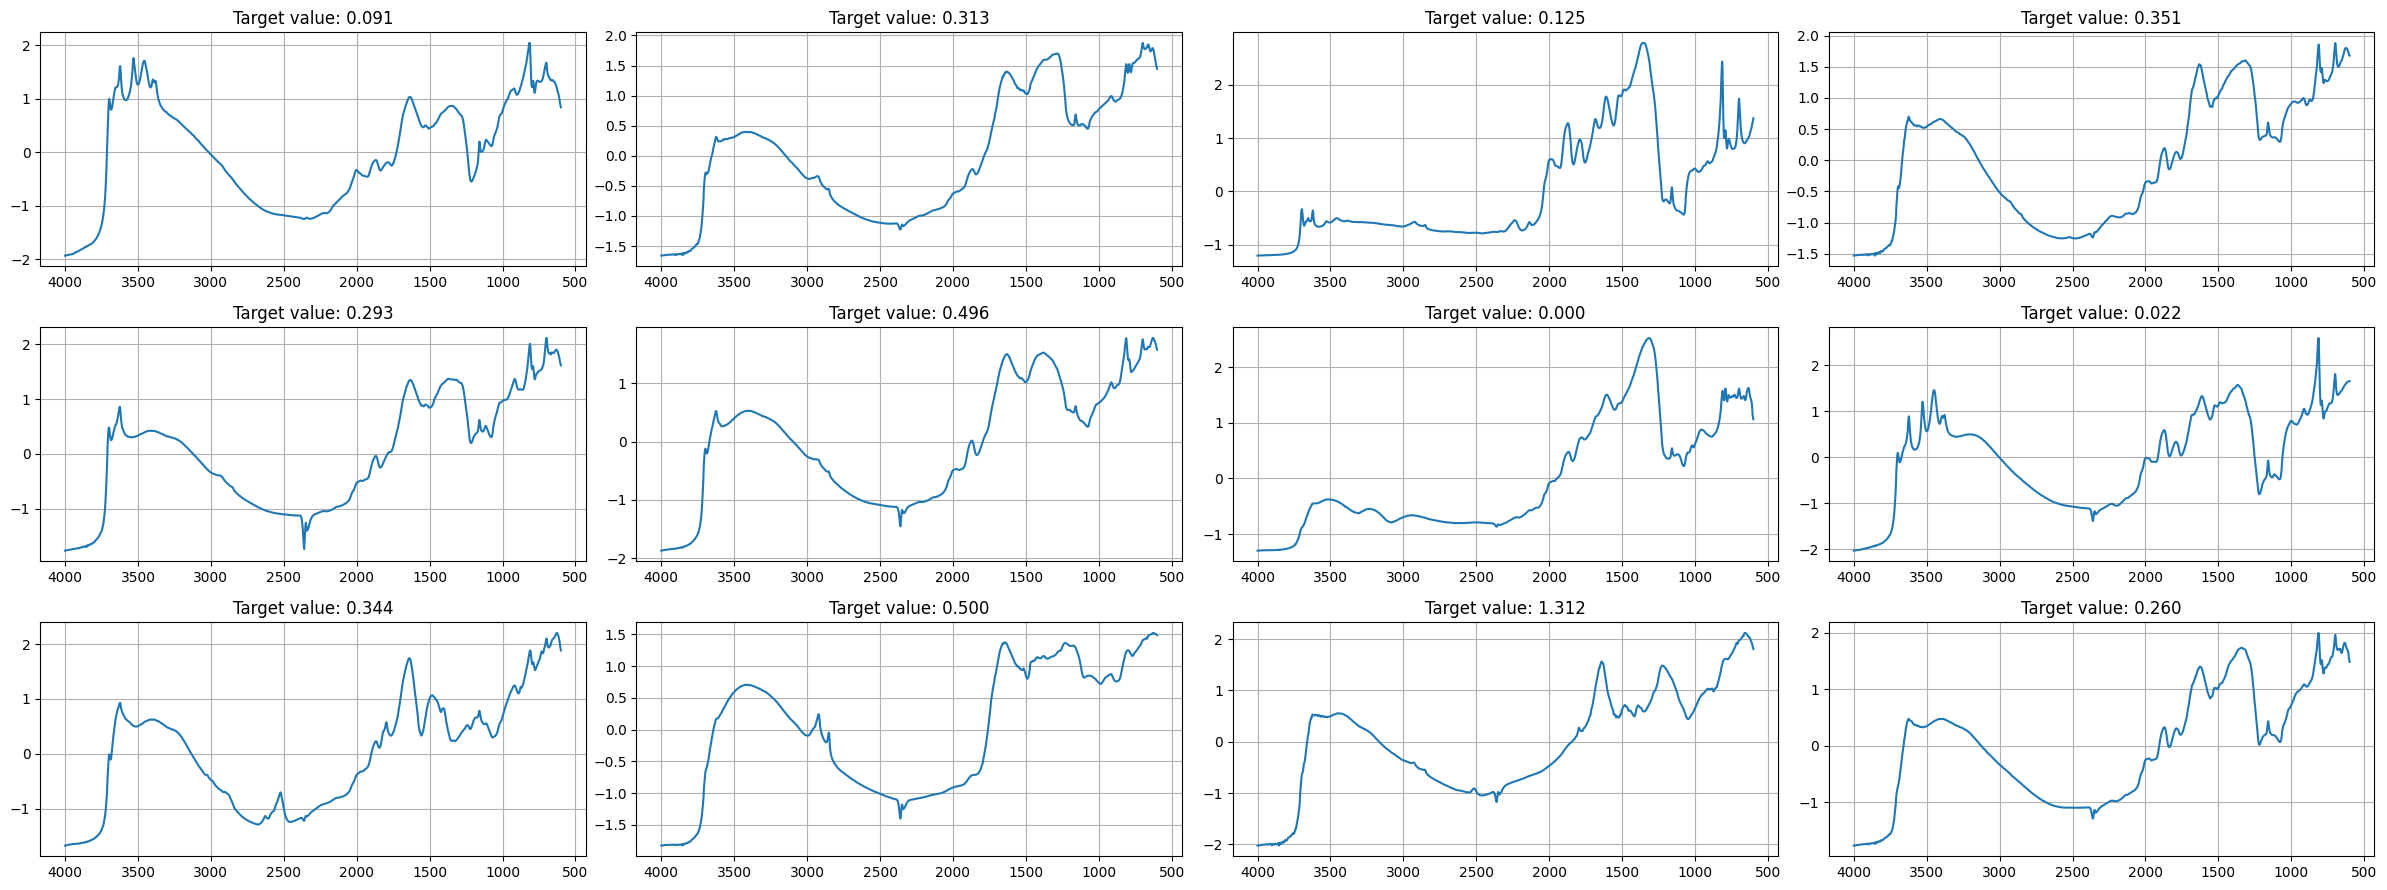

In [ ]:
#| eval: false
dls.show_batch(max_n=12, ncols=4)

In [ ]:
#| eval: false
from soilspecai.models import MirzaiCNN
from fastai.callback.schedule import lr_find

In [ ]:
#| eval: false
from fastai.learner import Learner
from fastai.losses import MSELossFlat

In [ ]:
#| eval: false
learn = Learner(dls, MirzaiCNN(), loss_func=MSELossFlat())
#learn.fit(5)

In [ ]:
#learn.lr_find()

In [ ]:
#| eval: false
from fastai.metrics import R2Score

In [ ]:
#| eval: false
learn = Learner(dls, MirzaiCNN(), loss_func=MSELossFlat(), metrics=R2Score())
learn.fit_one_cycle(1, lr_max=2e-3)

In [ ]:
#| eval: false
test_dl = dls.test_dl([X[i] for i in test_idx])
preds, _ = learn.get_preds(dl=test_dl);

TypeError: __repr__ returned non-string (type NoneType)

TypeError: __repr__ returned non-string (type NoneType)

In [ ]:
#| eval: false
preds

tensor([0.5452, 0.5281, 0.5544, 0.5254, 0.5217, 0.5391, 0.5274, 0.4785, 0.5322,
        0.5388, 0.4823, 0.5089, 0.5139, 0.4920, 0.5304, 0.4861, 0.5387, 0.5597,
        0.4168, 0.5007, 0.4465, 0.4894, 0.3981, 0.5012, 0.5379, 0.5219, 0.5327,
        0.5174, 0.5159, 0.5408, 0.5231, 0.5442, 0.4676, 0.5414, 0.4786, 0.4237,
        0.5017, 0.5202, 0.5493, 0.5361, 0.5026, 0.5366, 0.5414, 0.5066, 0.5154,
        0.5023, 0.5442, 0.5121, 0.5128, 0.4364, 0.5032, 0.5312, 0.3537, 0.5013,
        0.5213, 0.5275, 0.5451, 0.5031, 0.4469, 0.5436, 0.5010, 0.5291, 0.5079,
        0.5418, 0.4615, 0.5459, 0.4970, 0.4576, 0.4725, 0.5047, 0.5311, 0.5383,
        0.5612, 0.4602, 0.5296, 0.4918, 0.5469, 0.4485, 0.3970, 0.4975, 0.5422,
        0.5686, 0.5655, 0.5583, 0.4815, 0.5414, 0.5335, 0.4906, 0.5404, 0.4378,
        0.5045, 0.5194, 0.4431, 0.4818, 0.4541, 0.5123, 0.5219, 0.4937, 0.4915,
        0.4395])

In [ ]:
#| eval: false
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
#| eval: false
test_y = y[test_idx]
r2 = r2_score(test_y, preds.numpy().flatten())
rmse = np.sqrt(mean_squared_error(test_y, preds.numpy().flatten()))
print(f"R²: {r2:.4f}, RMSE: {rmse:.4f}")

If you look at the `data_fuku` dataset, it's a bit different from the `get_mir_k_1k_smp` one:
- we already have a train and test set
- we have also metadata we can use later on for error analysis (that can be further join via the id_). This is something we also should convey in the dataloader? potentially also displaying in show_batch?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;data_fuku[&#x27;meta&#x27;].head(2)&quot;)→&quot;PermissionError: Audit: fastaudit.call b…&quot;</code></summary>

```json
{
  "id": "call_00_XrFNP8FPEufC4HB6Y6Jm6632",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "data_fuku['meta'].head(2)"
    }
  },
  "result": "PermissionError: Audit: fastaudit.call blocked in sandbox with args: ('pandas.core.indexes.base.Index._validate_indexer', 'pandas._libs.lib.is_int_or_none')\nCall chain: runpy._run_module_as_main -> runpy._run_code -> __main__.<module> -> __main__.main -> __main__._run_kernel_from_cli -> ipymini.kernel.run_kernel -> ipymini.kernel.MiniKernel.start -> ipymini.kernel.Subshell.run_main -> ipymini.kernel.Subshell._run_loop_body -> asyncio.runners.Runner.run -> asyncio.base_events.BaseEventLoop.run_until_complete -> asyncio.base_events.BaseEventLoop.run_forever -> asyncio.base_events.BaseEventLoop._run_once -> asyncio.events.Handle._run -> microio._task.TaskGroup._run -> microio._task.TaskGroup._call_started -> microio._actor.ActorCore._handle_release -> ipymini.kernel.Subshell._handle_actor_item -> ipymini.kernel.Subshell._handle_message -> ipymini.kernel.Subshell._handle_execute -> ipymini.shell.shell.MiniShell.execute -> ipymini.shell.shell.MiniShell._run_cell -> IPython.core.interactiveshell.InteractiveShell.run_cell_async -> IPython.core.interactiveshell.InteractiveShell.run_ast_nodes -> IPython.core.interactiveshell.InteractiveShell.run_code -> __main__.<module> -> ipykernel_helper.core.call_tool -> fastcore.xtras.maybe_await -> safepyrun.core.RunPython.__call__ -> safepyrun.core._run_python -> safepyrun.core.__run_python -> safepyrun.core.__run_python.<locals>.run -> <python>.<module> -> pandas.core.generic.NDFrame.head -> pandas.core.indexing._LocationIndexer.__getitem__ -> pandas.core.indexing._iLocIndexer._getitem_axis -> pandas.core.indexing._iLocIndexer._get_slice_axis -> pandas.core.indexes.base.Index._validate_positional_slice -> pandas.core.indexes.base.Index._validate_indexer -> pandas._libs.lib.is_int_or_none. Code message has been added to dialog. Ask user to run it."
}
```

</details>



<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;list(data_fuku[&#x27;meta&#x27;].columns)&quot;)→&quot;Traceback (most recent call last):\n  Fil…&quot;</code></summary>

```json
{
  "id": "call_01_dEB77Q1vhM0WK8TT6Gfm6695",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "list(data_fuku['meta'].columns)"
    }
  },
  "result": "Traceback (most recent call last):\n  File \"/usr/local/lib/python3.12/site-packages/toolslm/funccall.py\", line 276, in call_func_async\n    res = await maybe_await(res)\n          ^^^^^^^^^^^^^^^^^^^^^^\n  File \"/usr/local/lib/python3.12/site-packages/fastcore/xtras.py\", line 1079, in maybe_await\n    return await o if isawaitable(o) else o\n           ^^^^^^^\n  File \"/root/solveit/solveit/aimsg.py\", line 234, in _f\n    await tmsg.exec(set_current=False)\n  File \"/root/solveit/solveit/runloop.py\", line 33, in exec\n    if self.msg_type==scode: await self.exec_code()\n                             ^^^^^^^^^^^^^^^^^^^^^^\n  File \"/root/solveit/solveit/kernel.py\", line 181, in exec_code\n    await self.dlg.kc.reply(self.content, msg_id=mid)\n  File \"/usr/local/lib/python3.12/site-packages/conkernelclient/core.py\", line 107, in _async_recv_reply\n    if isinstance(res, Exception): raise res\n                                   ^^^^^^^^^\nRuntimeError: Kernel error aborted: PermissionError: Audit: fastaudit.call blocked in sandbox with args: ('pandas.core.indexes.base.Index._validate_indexer', 'pandas._libs.lib.is_int_or_none')\nCall chain: runpy._run_module_as_main -> runpy._run_code -> __main__.<module> -> __main__.main -> __main__._run_kernel_from_cli -> ipymini.kernel.run_kernel -> ipymini.kernel.MiniKernel.start -> ipymini.kernel.Subshell.run_main -> ipymini.kernel.Subshell._run_loop_body -> asyncio.runners.Runner.run -> asyncio.base_events.BaseEventLoop.run_until_complete -> asyncio.base_events.BaseEventLoop.run_forever -> asyncio.base_events.BaseEventLoop._run_once -> asyncio.events.Handle._run -> microio._task.TaskGroup._run -> microio._task.TaskGroup._call_started -> microio._actor.ActorCore._handle_release -> ipymini.kernel.Subshell._handle_actor_item -> ipymini.kernel.Subshell._handle_message -> ipymini.kernel.Subshell._handle_execute -> ipymini.shell.shell.MiniShell.execute -> ipymini.shell.shell.MiniShell._run_cell -> IPython.core.interactiveshell.InteractiveShell.run_cell_async -> IPython.core.interactiveshell.InteractiveShell.run_ast_nodes -> IPython.core.interactiveshell.InteractiveShell.run_code -> __main__.<module> -> ipykernel_helper.core.call_tool -> fastcore.xtras.maybe_await -> safepyrun.core.RunPython.__call__ -> safepyrun.core._run_python -> safepyrun.core.__run_python -> safepyrun.core.__run_python.<locals>.run -> <python>.<module> -> pandas.core.generic.NDFrame.head -> pandas.core.indexing._LocationIndexer.__getitem__ -> pandas.core.indexing._iLocIndexer._getitem_axis -> pandas.core.indexing._iLocIndexer._get_slice_axis -> pandas.core.indexes.base.Index._validate_positional_slice -> pandas.core.indexes.base.Index._validate_indexer -> pandas._libs.lib.is_int_or_none"
}
```

</details>





Good question. From the data loading code I can see `data_fuku` has three relevant pieces:

- **Train/test**: pre-split with `id`, `X`, `y` (no splitter needed)
- **Metadata**: a DataFrame joinable via `ID` column — useful for error analysis later
- **wns**: already shared across both sets

The current `get_spectral_dls` assumes a single X/y and a splitter, so it doesn't directly handle this structure. A few design thoughts:

**For the dataloader itself**, I'd keep metadata separate from the training loop — it's an analysis tool, not an input to the model. Something like returning a combined meta DataFrame with predictions after inference would let you do grouped error analysis without complicating the DataBlock.

**For `show_batch`**, you could optionally display key metadata fields (location, soil type, date, etc.) as a subtitle on each spectrum plot — that helps spot whether errors cluster by a metadata category. But I'd make that opt-in (maybe the metadata columns to show passed as a parameter) rather than always on, since the MIR dataset doesn't have it.

Want me to sketch a small helper that merges metadata with predictions for error analysis? Or would you prefer to tackle the dataloader adaptation first?

<details class='token-usage-details' markdown='1'><summary>$0.0060</summary>

`total=75,508 | in=74,655 | out=853 | cached=71.2% | reasoning=490 | $0.0060 | deepseek-v4-flash`

</details>


I think for now the highest priority is to have a version of get_splitter that can accomodate already train/test splitted dataset

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Makes sense. Looking at the code, the current `get_spectral_dls` assumes one big X/y and a three-way splitter. For pre-split data like `data_fuku`, the simplest approach is a new entry point that handles it directly:

```python
def get_pre_split_dls(X_train, y_train, X_test, y_test, wns, valid_pct=0.1, bs=32, seed=42):
    "Create dataloaders from pre-split train/test data"
    TensorSpectrum.wns = wns
    n = len(X_train)
    np.random.seed(seed)
    shuffled = np.random.permutation(n)
    valid_size = int(valid_pct * n)
    train_idx = shuffled[:n-valid_size]
    valid_idx = shuffled[n-valid_size:]
    def _ds_splitter(o): return list(train_idx), list(valid_idx)
    items = list(range(n))
    dblock = DataBlock(blocks=(SpectralBlock(), RegressionBlock()), splitter=_ds_splitter,
        get_x=lambda i: X_train[i], get_y=lambda i: y_train[i])
    return dblock.dataloaders(items, bs=bs), X_test, y_test
```

This splits only the training data into train/valid, keeps test untouched, and returns both the `DataLoaders` and the test arrays for later evaluation. If you want a `get_splitter` version instead (that works within the existing `get_spectral_dls` signature), I can do that too — but this felt more direct since the data is already split.

<details class='token-usage-details' markdown='1'><summary>$0.0026</summary>

`total=40,482 | in=38,923 | out=1,559 | cached=84.2% | reasoning=1,215 | $0.0026 | deepseek-v4-flash`

</details>


In [ ]:
def get_pre_split_dls(X_train, y_train, X_test, y_test, wns, valid_pct=0.2, bs=32, seed=42):
    "Create dataloaders from pre-split train/test data"
    TensorSpectrum.wns = wns
    n = len(X_train)
    np.random.seed(seed)
    shuffled = np.random.permutation(n)
    valid_size = int(valid_pct * n)
    train_idx = shuffled[:n-valid_size]
    valid_idx = shuffled[n-valid_size:]
    def _ds_splitter(o): return list(train_idx), list(valid_idx)
    items = list(range(n))
    dblock = DataBlock(blocks=(SpectralBlock(), RegressionBlock()), splitter=_ds_splitter,
        get_x=lambda i: X_train[i], get_y=lambda i: y_train[i])
    return dblock.dataloaders(items, bs=bs), X_test, y_test

Can we try it?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
dls_fuku, X_test_fuku, y_test_fuku = get_pre_split_dls(data_fuku['train']['X'], data_fuku['train']['y'],
    data_fuku['test']['X'], data_fuku['test']['y'], data_fuku['wns'])
dls_fuku.show_batch(max_n=6, ncols=3)
```

<details class='token-usage-details' markdown='1'><summary>$0.0011</summary>

`total=39,693 | in=39,577 | out=116 | cached=97.7% | reasoning=34 | $0.0011 | deepseek-v4-flash`

</details>


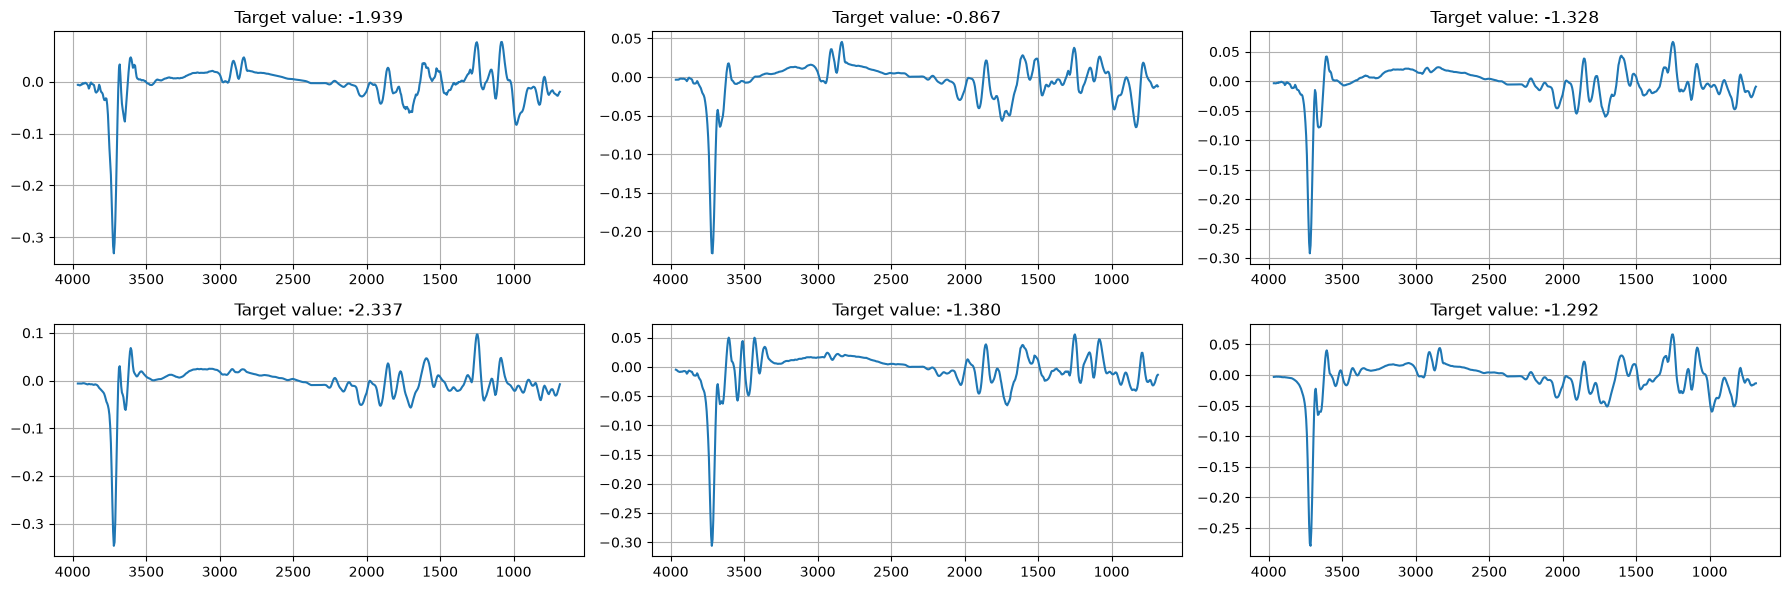

In [ ]:
dls_fuku, X_test_fuku, y_test_fuku = get_pre_split_dls(data_fuku['train']['X'], data_fuku['train']['y'],
    data_fuku['test']['X'], data_fuku['test']['y'], data_fuku['wns'])
dls_fuku.show_batch(max_n=6, ncols=3)

then to train it and evaluate on valid test?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
learn = Learner(dls_fuku, MirzaiCNN(), loss_func=MSELossFlat(), metrics=R2Score())
learn.fit_one_cycle(5, lr_max=2e-3)
```

<details class='token-usage-details' markdown='1'><summary>$0.0023</summary>

`total=40,300 | in=40,132 | out=168 | cached=81.7% | reasoning=119 | $0.0023 | deepseek-v4-flash`

</details>


In [ ]:
learn = Learner(dls_fuku, MirzaiCNN(), loss_func=MSELossFlat(), metrics=R2Score())
learn.fit_one_cycle(5, lr_max=2e-3)

epoch     train_loss  valid_loss  r2_score  time    


Epoch 1/5 : |----------------------------------------| 0.00% [0/29 00:00<?]

Epoch 1/5 : |█---------------------------------------| 3.45% [1/29 00:00<00:23]

Epoch 1/5 : |██--------------------------------------| 6.90% [2/29 00:00<00:12... 1.5344]

Epoch 1/5 : |████------------------------------------| 10.34% [3/29 00:01<00:08... 1.2861]

...

Epoch 5/5 : |█████████████████████████---------------| 62.50% [5/8 00:00<00:00... 0.1146]

Epoch 5/5 : |██████████████████████████████----------| 75.00% [6/8 00:00<00:00... 0.1146]

Epoch 5/5 : |███████████████████████████████████-----| 87.50% [7/8 00:00<00:00... 0.1146]

Epoch 5/5 : |████████████████████████████████████████| 100.00% [8/8 00:00<00:00... 0.1146]

4         0.114597    0.089237    0.355483  00:03     


In [ ]:
learn = Learner(dls_fuku, MirzaiCNN(), loss_func=MSELossFlat())

Epoch 1/4 : |----------------------------------------| 0.00% [0/29 00:00<?]

Epoch 1/4 : |█---------------------------------------| 3.45% [1/29 00:00<00:19]

Epoch 1/4 : |██--------------------------------------| 6.90% [2/29 00:01<00:16... 1.3590]

Epoch 1/4 : |████------------------------------------| 10.34% [3/29 00:01<00:14... 1.3784]

Epoch 1/4 : |█████-----------------------------------| 13.79% [4/29 00:01<00:10... 1.3736]

...

Epoch 4/4 : |█---------------------------------------| 3.45% [1/29 00:00<00:14]

Epoch 4/4 : |██--------------------------------------| 6.90% [2/29 00:00<00:07... 0.5175]

Epoch 4/4 : |████------------------------------------| 10.34% [3/29 00:00<00:05... 0.5328]

Epoch 4/4 : |█████-----------------------------------| 13.79% [4/29 00:00<00:03... 0.7467]

Epoch 4/4 : |██████----------------------------------| 17.24% [5/29 00:00<00:02... 0.8738]

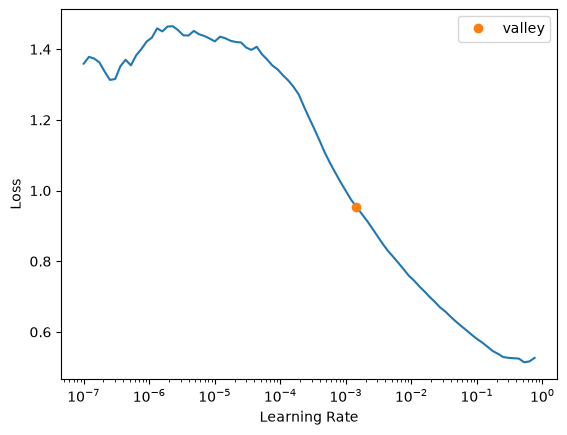

SuggestedLRs(valley=0.0014454397605732083)

In [ ]:
learn.lr_find()

In [ ]:
learn = Learner(dls_fuku, MirzaiCNN(), loss_func=MSELossFlat(), metrics=R2Score())
learn.fit_one_cycle(100, lr_max=2e-3)

epoch     train_loss  valid_loss  r2_score  time    


Epoch 1/100 : |----------------------------------------| 0.00% [0/29 00:00<?]

Epoch 1/100 : |█---------------------------------------| 3.45% [1/29 00:00<00:14]

Epoch 1/100 : |██--------------------------------------| 6.90% [2/29 00:00<00:08... 1.3819]

Epoch 1/100 : |████------------------------------------| 10.34% [3/29 00:00<00:06... 1.4654]

...

Epoch 100/100 : |█████████████████████████---------------| 62.50% [5/8 00:01<00:00... 0.0144]

Epoch 100/100 : |██████████████████████████████----------| 75.00% [6/8 00:01<00:00... 0.0144]

Epoch 100/100 : |███████████████████████████████████-----| 87.50% [7/8 00:01<00:00... 0.0144]

Epoch 100/100 : |████████████████████████████████████████| 100.00% [8/8 00:01<00:00... 0.0144]

99        0.014354    0.059794    0.568135  00:04     


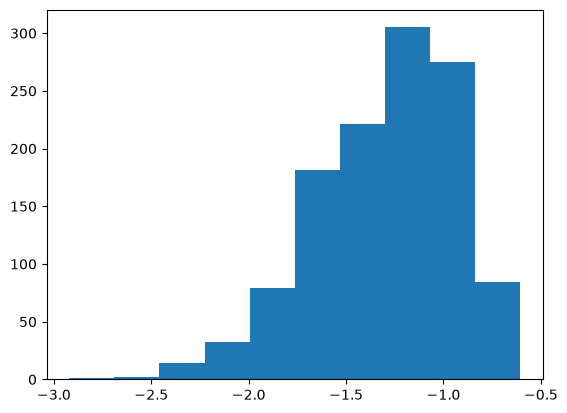

(array([  1.,   2.,  14.,  32.,  79., 181., 221., 305., 275.,  84.]),
 array([-2.92081875, -2.68932675, -2.45783474, -2.22634274, -1.99485073,
        -1.76335873, -1.53186672, -1.30037471, -1.06888271, -0.8373907 ,
        -0.6058987 ]),
 <BarContainer object of 10 artists>)

In [ ]:
plt.hist(y)

I'am able to reach an R2 of about 0.67 with cubist method and LS-SVM on this dataset. I believe I should at least reach the same performance with this CNN. Can we try to diagnose why? Several tracks:

- the target distribution
- we could diagnose why we forget at several epochs of the training for instance using the fastai `learn.activation_stats`. To do so we have to retrain and pass the `ActivationStats(with_hist=True)` callback to the Learner.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Good catches. The target histogram shows a roughly normal-ish distribution centered around -1.3 with left skew — that seems workable. The bigger red flag is the training instability: R² bounces from 0.57 to -0.08 to 0.53 across epochs, which suggests optimization issues.

Let's start with `ActivationStats`:

```python
from fastai.callback.hook import ActivationStats
act_stats = ActivationStats(with_hist=True)
learn = Learner(dls_fuku, MirzaiCNN(), loss_func=MSELossFlat(), metrics=R2Score(), cbs=act_stats)
learn.fit_one_cycle(10, lr_max=2e-3)
act_stats.plot_layer_stats()
```

Also worth checking the target distribution more closely:

```python
test_y_fuku.min(), test_y_fuku.max(), test_y_fuku.mean(), test_y_fuku.std()
```

<details class='token-usage-details' markdown='1'><summary>$0.0029</summary>

`total=43,506 | in=42,916 | out=590 | cached=77.8% | reasoning=399 | $0.0029 | deepseek-v4-flash`

</details>


In [ ]:
from fastai.callback.hook import ActivationStats
act_stats = ActivationStats(with_hist=True)
learn = Learner(dls_fuku, MirzaiCNN(), loss_func=MSELossFlat(), metrics=R2Score(), cbs=act_stats)
learn.fit_one_cycle(10, lr_max=2e-3)
act_stats.plot_layer_stats()

/app/data/.local/lib/python3.12/site-packages/fastai/callback/core.py:71: UserWarning: You are shadowing an attribute (modules) that exists in the learner. Use `self.learn.modules` to avoid this
  warn(f"You are shadowing an attribute ({name}) that exists in the learner. Use `self.learn.{name}` to avoid this")


epoch     train_loss  valid_loss  r2_score  time    


Epoch 1/10 : |----------------------------------------| 0.00% [0/29 00:00<?]

Epoch 1/10 : |█---------------------------------------| 3.45% [1/29 00:01<00:42]

Epoch 1/10 : |██--------------------------------------| 6.90% [2/29 00:01<00:22... 2.1941]

...

Epoch 10/10 : |██████████████████████████████----------| 75.00% [6/8 00:02<00:00... 0.0864]

Epoch 10/10 : |███████████████████████████████████-----| 87.50% [7/8 00:02<00:00... 0.0864]

Epoch 10/10 : |████████████████████████████████████████| 100.00% [8/8 00:02<00:00... 0.0864]

9         0.086439    0.073663    0.467969  00:07     


TypeError: ActivationStats.plot_layer_stats() missing 1 required positional argument: 'idx'

see error above

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
learn.activation_stats.plot_layer_stats(idx=-2)
```

Or multiple layers:

```python
learn.activation_stats.plot_layer_stats(idx=-1)
```

<details class='token-usage-details' markdown='1'><summary>$0.0022</summary>

`total=43,793 | in=43,734 | out=59 | cached=84.3% | reasoning=24 | $0.0022 | deepseek-v4-flash`

</details>


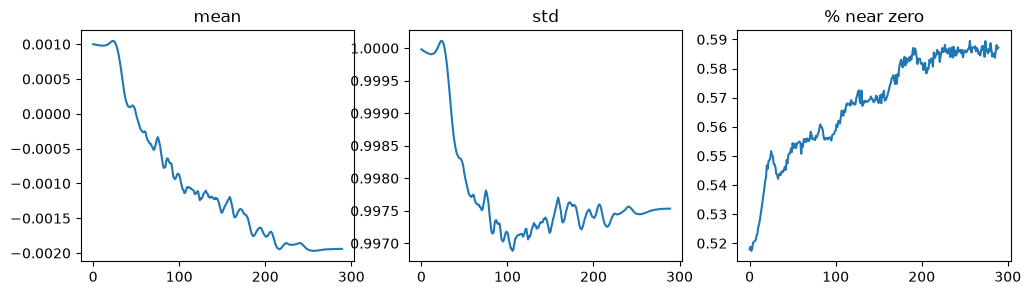

In [ ]:
learn.activation_stats.plot_layer_stats(idx=-2)

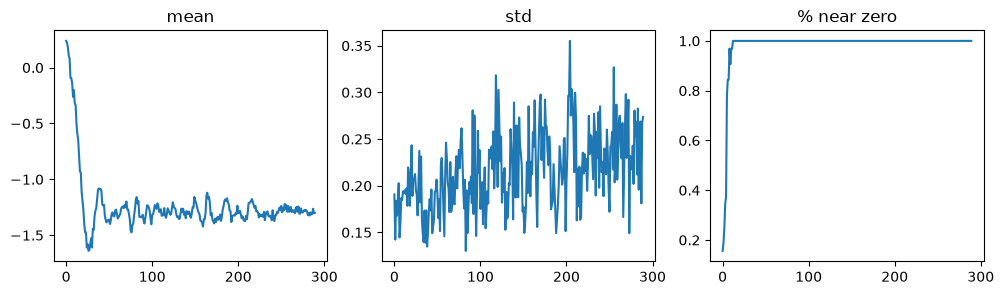

In [ ]:
learn.activation_stats.plot_layer_stats(idx=-1)

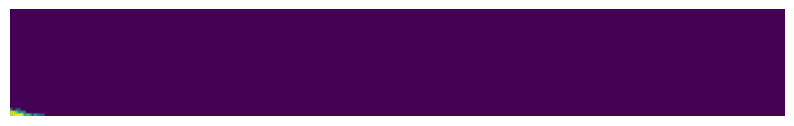

In [ ]:
learn.activation_stats.color_dim(-1)

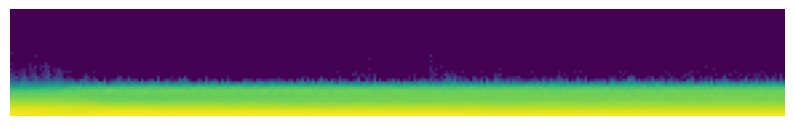

In [ ]:
learn.activation_stats.color_dim(-2)

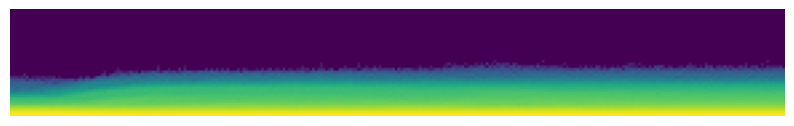

In [ ]:
learn.activation_stats.color_dim(-3)

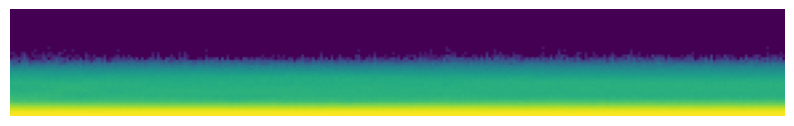

In [ ]:
learn.activation_stats.color_dim(-4)

In [ ]:
y.min(), y.max(), y.mean(), y.std()

(np.float64(-2.920818753952376),
 np.float64(-0.6058986979599553),
 np.float64(-1.3015377101405492),
 np.float64(0.3556855271979616))

Above some layers activation diagnosis

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

The activation stats reveal a clear problem:

- **Layer -2**: ~55-59% of activations are near zero, mean drifts to -1.5, std only ~0.2 — most neurons are dead
- **Layer -1**: 100% near zero (expected for regression output, but the input to it is already mostly dead)
- **Color dim plots**: sparse activity concentrated at the bottom (near-zero values)

The network is losing signal through the layers. Let's check if batch norm is being used and look at earlier layers:

```python
learn.activation_stats.plot_layer_stats(idx=0)
```

Also, let's check the model architecture:

```python
learn.model
```

<details class='token-usage-details' markdown='1'><summary>$0.0304</summary>

`total=49,350 | in=48,909 | out=441 | cached=0.0% | $0.0304 | qwen3p7-plus`

</details>


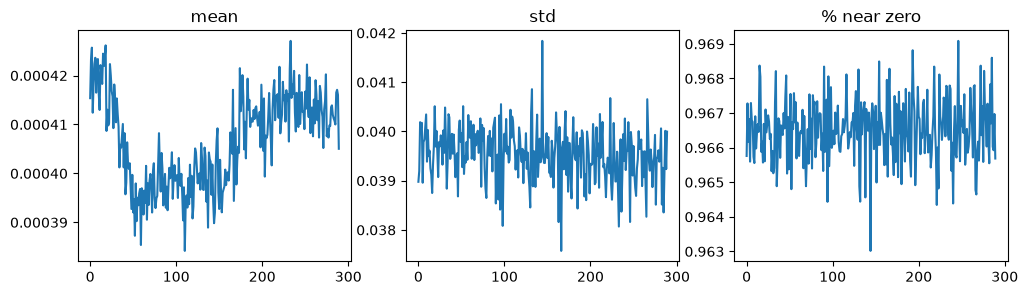

In [ ]:
learn.activation_stats.plot_layer_stats(idx=0)

In [ ]:
learn.model

MirzaiCNN(
  (backbone): FeatureExtractor(
    (layers): Sequential(
      (0): ConvBlock(
        (conv): ConvLayer(
          (0): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
          (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): LeakyReLU(negative_slope=0.1)
        )
        (pool): AvgPool1d(kernel_size=(3,), stride=(3,), padding=(0,))
      )
      (1): ConvBlock(
        (conv): ConvLayer(
          (0): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
          (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): LeakyReLU(negative_slope=0.1)
        )
        (pool): AvgPool1d(kernel_size=(3,), stride=(3,), padding=(0,))
      )
      (2): ConvBlock(
        (conv): ConvLayer(
          (0): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
          (1): BatchNorm1d(64, eps=1e-05, mo

Based on the model architecture and last layer stats, what's your feeling?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

The activation stats tell a clear story:

**Layer 0 (first conv output)**: 96.7% near zero, mean=0.0004, std=0.04 — the very first layer is producing nearly dead activations. This is the root cause.

**Layer -2 (last conv)**: 55-59% near zero, mean=-1.5, std=0.2 — signal has degraded further through the network.

The most likely culprit: **the input spectra aren't normalized**. Looking at the show_batch plots, values range from roughly -0.3 to 0.1. With such small, unstandardized inputs flowing through BatchNorm → LeakyReLU → pooling five times, the activations collapse.

Two fixes to try:

1. **Standardize the input spectra** (per-wavenumber z-score normalization)
2. **Reduce dropout** from 0.4 to 0.1-0.2 (aggressive for regression with ~1200 samples)

Want me to add input normalization to the `SpectralBlock` transform?

<details class='token-usage-details' markdown='1'><summary>$0.0092</summary>

`total=51,650 | in=50,354 | out=1,296 | cached=99.6% | $0.0092 | qwen3p7-plus`

</details>


- can you further explain why standardization would help. I am using batchnorm after each conv layer right? Also if standardization shoulr appear, it should be done row/spectrum-wise not column/wavenumber wise to preserve spectrum shape
- how can dropout affect?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Good questions.

**BatchNorm vs input standardization:**

BatchNorm normalizes *across the batch* for each channel. So for Conv1d output shape `(batch, channels, length)`, it normalizes each of the 16/32/64... channels independently across your batch of ~32 samples. This helps with internal covariate shift *within* the network.

But the problem is at the *input* to the first conv. Your spectra range roughly -0.3 to 0.1 (from the show_batch plots). With these small values and randomly initialized conv weights, the first layer outputs have std=0.04 as we saw. When BatchNorm tries to normalize activations with variance that small, the epsilon term (1e-5) becomes significant relative to the actual variance, making normalization unstable. The running mean/variance estimates also become unreliable.

So BatchNorm helps *after* the first layer produces reasonable activations, but it can't fix inputs that are too small to begin with.

You're right about row-wise normalization. For spectroscopy, column-wise normalization would destroy the spectral features (absorption peaks, etc.). Row-wise (per-spectrum) standardization subtracts each spectrum's mean and divides by its std, preserving the shape while scaling the magnitude to a reasonable range.

**Dropout:**

With 1200 samples and dropout=0.4, you're randomly zeroing 40% of the 256 features before the final linear layer. That leaves ~154 active features per forward pass on average. For regression with limited data, this:

- Adds significant noise to gradient updates
- Slows convergence (explains the R² bouncing between epochs)
- Can prevent stable feature learning
- May be unnecessary regularization for this problem size

For regression with ~1200 samples, 0.1-0.2 is more typical. Some spectroscopy regression tasks work well with no dropout at all.

<details class='token-usage-details' markdown='1'><summary>$0.0327</summary>

`total=51,681 | in=50,722 | out=959 | cached=0.0% | $0.0327 | qwen3p7-plus`

</details>


ok add a normalization layer first

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
def SpectralBlock():
    def _norm(x):
        x = torch.tensor(x, dtype=torch.float32)
        return (x - x.mean()) / (x.std() + 1e-8)
    return TransformBlock(type_tfms=lambda x: TensorSpectrum(_norm(x).unsqueeze(0)))
```

<details class='token-usage-details' markdown='1'><summary>$0.0320</summary>

`total=51,755 | in=51,221 | out=534 | cached=0.0% | $0.0320 | qwen3p7-plus`

</details>


In [ ]:
def SpectralBlock():
    def _norm(x):
        x = torch.tensor(x, dtype=torch.float32)
        return (x - x.mean()) / (x.std() + 1e-8)
    return TransformBlock(type_tfms=lambda x: TensorSpectrum(_norm(x).unsqueeze(0)))

then?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
dls_fuku, X_test_fuku, y_test_fuku = get_pre_split_dls(data_fuku['train']['X'], data_fuku['train']['y'],
    data_fuku['test']['X'], data_fuku['test']['y'], data_fuku['wns'])
learn = Learner(dls_fuku, MirzaiCNN(), loss_func=MSELossFlat(), metrics=R2Score())
learn.fit_one_cycle(10, lr_max=2e-3)
```

<details class='token-usage-details' markdown='1'><summary>$0.0071</summary>

`total=51,632 | in=51,502 | out=130 | cached=97.4% | $0.0071 | qwen3p7-plus`

</details>


In [ ]:
dls_fuku, X_test_fuku, y_test_fuku = get_pre_split_dls(data_fuku['train']['X'], data_fuku['train']['y'],
    data_fuku['test']['X'], data_fuku['test']['y'], data_fuku['wns'])

act_stats = ActivationStats(with_hist=True)
learn = Learner(dls_fuku, MirzaiCNN(), loss_func=MSELossFlat(), metrics=R2Score(), cbs=act_stats)
learn.fit_one_cycle(10, lr_max=2e-3)

/app/data/.local/lib/python3.12/site-packages/fastai/callback/core.py:71: UserWarning: You are shadowing an attribute (modules) that exists in the learner. Use `self.learn.modules` to avoid this
  warn(f"You are shadowing an attribute ({name}) that exists in the learner. Use `self.learn.{name}` to avoid this")


epoch     train_loss  valid_loss  r2_score  time    


Epoch 1/10 : |----------------------------------------| 0.00% [0/29 00:00<?]

Epoch 1/10 : |█---------------------------------------| 3.45% [1/29 00:01<00:46]

Epoch 1/10 : |██--------------------------------------| 6.90% [2/29 00:02<00:27... 2.9951]

...

Epoch 10/10 : |█████████████████████████---------------| 62.50% [5/8 00:01<00:00... 0.0815]

Epoch 10/10 : |██████████████████████████████----------| 75.00% [6/8 00:01<00:00... 0.0815]

Epoch 10/10 : |███████████████████████████████████-----| 87.50% [7/8 00:01<00:00... 0.0815]

Epoch 10/10 : |████████████████████████████████████████| 100.00% [8/8 00:01<00:00... 0.0815]

9         0.081524    0.071530    0.483373  00:04     


looks better?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Yes, much more stable — no more wild negative R² swings. But 0.45 is still below our 0.67 target. Let's train for longer to see if it keeps climbing:

```python
learn.fit_one_cycle(50, lr_max=2e-3)
```

<details class='token-usage-details' markdown='1'><summary>$0.0333</summary>

`total=53,072 | in=52,262 | out=810 | cached=0.0% | $0.0333 | qwen3p7-plus`

</details>


Can't we check/visualize activation_stats before?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
learn.activation_stats.plot_layer_stats(idx=0)
```

<details class='token-usage-details' markdown='1'><summary>$0.0065</summary>

`total=52,452 | in=52,414 | out=38 | cached=99.6% | $0.0065 | qwen3p7-plus`

</details>


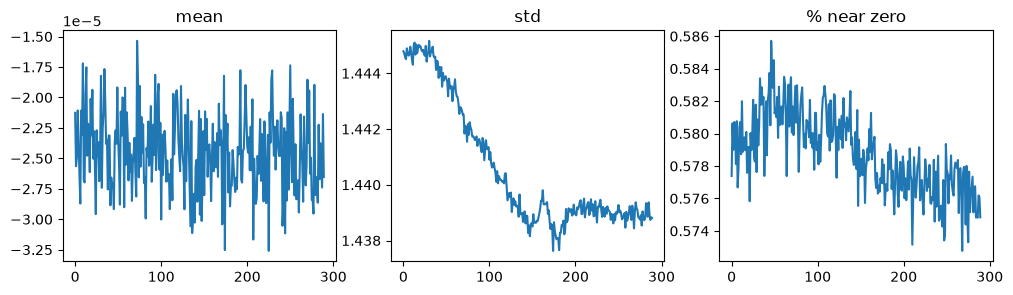

In [ ]:
learn.activation_stats.plot_layer_stats(idx=0)

Still same issue

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
batch = dls_fuku.train_batch
x, y = next(iter(dls_fuku.train))
x.mean().item(), x.std().item()
```

<details class='token-usage-details' markdown='1'><summary>$0.0333</summary>

`total=53,595 | in=52,984 | out=611 | cached=0.0% | $0.0333 | qwen3p7-plus`

</details>


In [ ]:
batch = dls_fuku.train_batch
x, y = next(iter(dls_fuku.train))
x.mean().item(), x.std().item()

AttributeError: train_batch

see error above

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
x, y = dls_fuku.train.one_batch()
x.mean().item(), x.std().item()
```

<details class='token-usage-details' markdown='1'><summary>$0.0073</summary>

`total=53,682 | in=53,610 | out=72 | cached=97.4% | $0.0073 | qwen3p7-plus`

</details>


In [ ]:
x, y = dls_fuku.train.one_batch()
x.mean().item(), x.std().item()

(2.2453805481603695e-09, 0.9992620944976807)

so?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Input is well normalized (mean≈0, std≈1), so that's not the issue. The problem is the activations are still degrading through the network.

Let's check the spatial dimensions through the network:

```python
x.shape
```

With 5 ConvBlocks each doing 3x pooling, a 1701-length input becomes 1701/3^5 ≈ 7 timesteps before the adaptive pool. That's aggressive dimensionality reduction - we might be losing spectral resolution.

Two options:
1. **Reduce pooling** - use stride=2 instead of 3, or skip pooling in some blocks
2. **Try a simpler architecture** - fewer conv layers, or use 1x1 convolutions to preserve spatial resolution

Want me to check the actual output shape first?

<details class='token-usage-details' markdown='1'><summary>$0.0091</summary>

`total=54,819 | in=53,843 | out=976 | cached=98.9% | $0.0091 | qwen3p7-plus`

</details>


In [ ]:
X.shape

(1194, 657)

Look actually we have only 657 features

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Right, 657 features. With 5 pooling layers of stride=3:

657 → 219 → 73 → 24 → 8 → 2

We end up with only 2 timesteps before adaptive pooling. That's losing most of the spectral information. Let's check the actual output shape:

```python
x, y = dls_fuku.train.one_batch()
learn.model.backbone(x).shape
```

<details class='token-usage-details' markdown='1'><summary>$0.0075</summary>

`total=54,414 | in=54,176 | out=238 | cached=98.3% | $0.0075 | qwen3p7-plus`

</details>


In [ ]:
x, y = dls_fuku.train.one_batch()
learn.model.backbone(x).shape

torch.Size([32, 256, 1])

what do you suggest?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

With 657 features and 5 pooling layers (stride=3), we go: 657→219→73→24→8→2→1. We're crushing the spatial resolution.

Two options:

1. **Reduce pooling** - modify the backbone to use fewer ConvBlocks or stride=2 pooling
2. **Try a simpler baseline first** - PLS or ridge regression to establish what's achievable

For option 1, we'd need to modify the MirzaiCNN architecture. For option 2:

```python
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score

pls = PLSRegression(n_components=20)
pls.fit(X_train, y_train)
r2_score(y_test, pls.predict(X_test).flatten())
```

Want to try the PLS baseline first to see what's achievable, or dive into modifying the CNN architecture?

<details class='token-usage-details' markdown='1'><summary>$0.0082</summary>

`total=54,919 | in=54,450 | out=469 | cached=97.8% | $0.0082 | qwen3p7-plus`

</details>


In [ ]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score

pls = PLSRegression(n_components=20)
pls.fit(data_fuku['train']['X'], data_fuku['train']['y'])
r2_score(data_fuku['test']['y'], pls.predict(data_fuku['test']['X']).flatten())

0.5464933366065876

Ok here above the baseline. Now let's adress MirzaiCNN architecture here. Calling it FukuCNN.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
class FukuCNN(Module):
    def __init__(self, n_in=1, n_out=1):
        self.backbone = nn.Sequential(
            ConvBlock(n_in, 32, pool_sz=2),
            ConvBlock(32, 64, pool_sz=2),
            ConvBlock(64, 128, pool_sz=2),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
        )
        self.head = nn.Sequential(nn.Dropout(0.2), nn.Linear(128, n_out))
    
    def forward(self, x): return self.head(self.backbone(x))
```

With stride=2 pooling: 657→328→164→82→1, preserving much more spectral resolution.

<details class='token-usage-details' markdown='1'><summary>$0.0081</summary>

`total=55,410 | in=54,900 | out=510 | cached=98.9% | $0.0081 | qwen3p7-plus`

</details>


In [ ]:
from functools import partial
import torch
import torch.nn as nn
from torch.nn import (Module, AvgPool1d, LeakyReLU,
                      AdaptiveAvgPool1d, Sequential, 
                      Dropout, Linear)

from fastai.layers import ConvLayer
from typing import Callable

class ConvBlock(Module):
    def __init__(self, n_in, n_out, pool_sz=2):
        self.conv = ConvLayer(n_in, n_out, ks=3, act_cls=LeakyReLU, norm_type=NormType.Batch)
        self.pool = AvgPool1d(pool_sz)
    def forward(self, x): return self.pool(self.conv(x))

class FukuCNN(Module):
    def __init__(self, n_in=1, n_out=1):
        self.backbone = nn.Sequential(
            ConvBlock(n_in, 32, pool_sz=2),
            ConvBlock(32, 64, pool_sz=2),
            ConvBlock(64, 128, pool_sz=2),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
        )
        self.head = nn.Sequential(nn.Dropout(0.2), nn.Linear(128, n_out))
    
    def forward(self, x): return self.head(self.backbone(x))

then?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
dls_fuku, X_test_fuku, y_test_fuku = get_pre_split_dls(data_fuku['train']['X'], data_fuku['train']['y'],
    data_fuku['test']['X'], data_fuku['test']['y'], data_fuku['wns'])
learn = Learner(dls_fuku, FukuCNN(), loss_func=MSELossFlat(), metrics=R2Score())
learn.fit_one_cycle(20, lr_max=2e-3)
```

<details class='token-usage-details' markdown='1'><summary>$0.0076</summary>

`total=55,579 | in=55,419 | out=160 | cached=97.9% | $0.0076 | qwen3p7-plus`

</details>


Always add the activation stat callback in your code suggestion for now

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
act_stats = ActivationStats(with_hist=True)
learn = Learner(dls_fuku, FukuCNN(), loss_func=MSELossFlat(), metrics=R2Score(), cbs=act_stats)
learn.fit_one_cycle(20, lr_max=2e-3)
act_stats.plot_layer_stats(idx=0)
```

<details class='token-usage-details' markdown='1'><summary>$0.0108</summary>

`total=57,080 | in=55,617 | out=1,463 | cached=97.6% | $0.0108 | qwen3p7-plus`

</details>


In [ ]:
act_stats = ActivationStats(with_hist=True)
learn = Learner(dls_fuku, FukuCNN(), loss_func=MSELossFlat(), metrics=R2Score(), cbs=act_stats)
learn.fit_one_cycle(20, lr_max=2e-3)
act_stats.plot_layer_stats(idx=0)

NameError: name 'ConvBlock' is not defined

fix the error above

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
class ConvBlock(Module):
    def __init__(self, n_in, n_out, pool_sz=2):
        self.conv = ConvLayer(n_in, n_out, ks=3, act_cls=LeakyReLU, norm_type=NormType.Batch)
        self.pool = AvgPool1d(pool_sz)
    def forward(self, x): return self.pool(self.conv(x))

class FukuCNN(Module):
    def __init__(self, n_in=1, n_out=1):
        self.backbone = nn.Sequential(
            ConvBlock(n_in, 32, pool_sz=2),
            ConvBlock(32, 64, pool_sz=2),
            ConvBlock(64, 128, pool_sz=2),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
        )
        self.head = nn.Sequential(nn.Dropout(0.2), nn.Linear(128, n_out))
    
    def forward(self, x): return self.head(self.backbone(x))
```

```python
act_stats = ActivationStats(with_hist=True)
learn = Learner(dls_fuku, FukuCNN(), loss_func=MSELossFlat(), metrics=R2Score(), cbs=act_stats)
learn.fit_one_cycle(20, lr_max=2e-3)
act_stats.plot_layer_stats(idx=0)
```

<details class='token-usage-details' markdown='1'><summary>$0.0090</summary>

`total=56,725 | in=56,168 | out=557 | cached=96.6% | $0.0090 | qwen3p7-plus`

</details>


In [ ]:
act_stats = ActivationStats(with_hist=True)
learn = Learner(dls_fuku, FukuCNN(), loss_func=MSELossFlat(), metrics=R2Score(), cbs=act_stats)
learn.fit_one_cycle(20, lr_max=2e-3)
act_stats.plot_layer_stats(idx=0)

NameError: name 'NormType' is not defined

see error above

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
from fastai.layers import ConvLayer, NormType
```

```python
class ConvBlock(Module):
    def __init__(self, n_in, n_out, pool_sz=2):
        self.conv = ConvLayer(n_in, n_out, ks=3, act_cls=LeakyReLU, norm_type=NormType.Batch)
        self.pool = AvgPool1d(pool_sz)
    def forward(self, x): return self.pool(self.conv(x))

class FukuCNN(Module):
    def __init__(self, n_in=1, n_out=1):
        self.backbone = nn.Sequential(
            ConvBlock(n_in, 32, pool_sz=2),
            ConvBlock(32, 64, pool_sz=2),
            ConvBlock(64, 128, pool_sz=2),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
        )
        self.head = nn.Sequential(nn.Dropout(0.2), nn.Linear(128, n_out))
    
    def forward(self, x): return self.head(self.backbone(x))
```

```python
act_stats = ActivationStats(with_hist=True)
learn = Learner(dls_fuku, FukuCNN(), loss_func=MSELossFlat(), metrics=R2Score(), cbs=act_stats)
learn.fit_one_cycle(20, lr_max=2e-3)
act_stats.plot_layer_stats(idx=0)
```

<details class='token-usage-details' markdown='1'><summary>$0.0091</summary>

`total=57,516 | in=57,137 | out=379 | cached=95.0% | $0.0091 | qwen3p7-plus`

</details>


In [ ]:
from fastai.layers import ConvLayer, NormType

In [ ]:
class ConvBlock(Module):
    def __init__(self, n_in, n_out, pool_sz=2):
        self.conv = ConvLayer(n_in, n_out, ks=3, act_cls=LeakyReLU, norm_type=NormType.Batch)
        self.pool = AvgPool1d(pool_sz)
    def forward(self, x): return self.pool(self.conv(x))

class FukuCNN(Module):
    def __init__(self, n_in=1, n_out=1):
        self.backbone = nn.Sequential(
            ConvBlock(n_in, 32, pool_sz=2),
            ConvBlock(32, 64, pool_sz=2),
            ConvBlock(64, 128, pool_sz=2),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
        )
        self.head = nn.Sequential(nn.Dropout(0.2), nn.Linear(128, n_out))
    
    def forward(self, x): return self.head(self.backbone(x))

In [ ]:
act_stats = ActivationStats(with_hist=True)
learn = Learner(dls_fuku, FukuCNN(), loss_func=MSELossFlat(), metrics=R2Score(), cbs=act_stats)
learn.fit_one_cycle(20, lr_max=2e-3)
act_stats.plot_layer_stats(idx=0)

AttributeError: cannot assign module before Module.__init__() call

see error above

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
class ConvBlock(Module):
    def __init__(self, n_in, n_out, pool_sz=2):
        super().__init__()
        self.conv = ConvLayer(n_in, n_out, ks=3, act_cls=LeakyReLU, norm_type=NormType.Batch)
        self.pool = AvgPool1d(pool_sz)
    def forward(self, x): return self.pool(self.conv(x))

class FukuCNN(Module):
    def __init__(self, n_in=1, n_out=1):
        super().__init__()
        self.backbone = nn.Sequential(
            ConvBlock(n_in, 32, pool_sz=2),
            ConvBlock(32, 64, pool_sz=2),
            ConvBlock(64, 128, pool_sz=2),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
        )
        self.head = nn.Sequential(nn.Dropout(0.2), nn.Linear(128, n_out))
    
    def forward(self, x): return self.head(self.backbone(x))
```

```python
act_stats = ActivationStats(with_hist=True)
learn = Learner(dls_fuku, FukuCNN(), loss_func=MSELossFlat(), metrics=R2Score(), cbs=act_stats)
learn.fit_one_cycle(20, lr_max=2e-3)
act_stats.plot_layer_stats(idx=0)
```

<details class='token-usage-details' markdown='1'><summary>$0.0091</summary>

`total=58,994 | in=58,581 | out=413 | cached=96.1% | $0.0091 | qwen3p7-plus`

</details>


In [ ]:
class ConvBlock(Module):
    def __init__(self, n_in, n_out, pool_sz=2):
        super().__init__()
        self.conv = ConvLayer(n_in, n_out, ks=3, act_cls=LeakyReLU, norm_type=NormType.Batch)
        self.pool = AvgPool1d(pool_sz)
    def forward(self, x): return self.pool(self.conv(x))

class FukuCNN(Module):
    def __init__(self, n_in=1, n_out=1):
        super().__init__()
        self.backbone = nn.Sequential(
            ConvBlock(n_in, 32, pool_sz=2),
            ConvBlock(32, 64, pool_sz=2),
            ConvBlock(64, 128, pool_sz=2),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
        )
        self.head = nn.Sequential(nn.Dropout(0.2), nn.Linear(128, n_out))
    
    def forward(self, x): return self.head(self.backbone(x))

In [ ]:
act_stats = ActivationStats(with_hist=True)
learn = Learner(dls_fuku, FukuCNN(), loss_func=MSELossFlat(), metrics=R2Score(), cbs=act_stats)
learn.fit_one_cycle(20, lr_max=2e-3)

/app/data/.local/lib/python3.12/site-packages/fastai/callback/core.py:71: UserWarning: You are shadowing an attribute (modules) that exists in the learner. Use `self.learn.modules` to avoid this
  warn(f"You are shadowing an attribute ({name}) that exists in the learner. Use `self.learn.{name}` to avoid this")


epoch     train_loss  valid_loss  r2_score  time    


Epoch 1/20 : |----------------------------------------| 0.00% [0/29 00:00<?]

RuntimeError: Given groups=1, weight of size [32, 1, 3, 3], expected input[1, 32, 1, 657] to have 1 channels, but got 32 channels instead

Check carefully and fix please

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
class ConvBlock(Module):
    def __init__(self, n_in, n_out, pool_sz=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_in, n_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(n_out),
            nn.LeakyReLU(0.1),
        )
        self.pool = nn.AvgPool1d(pool_sz)
    def forward(self, x): return self.pool(self.conv(x))

class FukuCNN(Module):
    def __init__(self, n_in=1, n_out=1):
        super().__init__()
        self.backbone = nn.Sequential(
            ConvBlock(n_in, 32, pool_sz=2),
            ConvBlock(32, 64, pool_sz=2),
            ConvBlock(64, 128, pool_sz=2),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
        )
        self.head = nn.Sequential(nn.Dropout(0.2), nn.Linear(128, n_out))
    
    def forward(self, x): return self.head(self.backbone(x))
```

```python
act_stats = ActivationStats(with_hist=True)
learn = Learner(dls_fuku, FukuCNN(), loss_func=MSELossFlat(), metrics=R2Score(), cbs=act_stats)
learn.fit_one_cycle(20, lr_max=2e-3)
act_stats.plot_layer_stats(idx=0)
```

<details class='token-usage-details' markdown='1'><summary>$0.0113</summary>

`total=63,627 | in=63,006 | out=621 | cached=92.6% | $0.0113 | qwen3p7-plus`

</details>


In [ ]:
class ConvBlock(Module):
    def __init__(self, n_in, n_out, pool_sz=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_in, n_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(n_out),
            nn.LeakyReLU(0.1),
        )
        self.pool = nn.AvgPool1d(pool_sz)
    def forward(self, x): return self.pool(self.conv(x))

class FukuCNN(Module):
    def __init__(self, n_in=1, n_out=1):
        super().__init__()
        self.backbone = nn.Sequential(
            ConvBlock(n_in, 32, pool_sz=2),
            ConvBlock(32, 64, pool_sz=2),
            ConvBlock(64, 128, pool_sz=2),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
        )
        self.head = nn.Sequential(nn.Dropout(0.2), nn.Linear(128, n_out))
    
    def forward(self, x): return self.head(self.backbone(x))

epoch     train_loss  valid_loss  r2_score  time    


Epoch 1/20 : |----------------------------------------| 0.00% [0/29 00:00<?]

Epoch 1/20 : |█---------------------------------------| 3.45% [1/29 00:01<00:39]

Epoch 1/20 : |██--------------------------------------| 6.90% [2/29 00:02<00:29... 2.3515]

Epoch 1/20 : |████------------------------------------| 10.34% [3/29 00:02<00:24... 2.2423]

...

Epoch 20/20 : |█████████████████████████---------------| 62.50% [5/8 00:01<00:00... 0.0941]

Epoch 20/20 : |██████████████████████████████----------| 75.00% [6/8 00:01<00:00... 0.0941]

Epoch 20/20 : |███████████████████████████████████-----| 87.50% [7/8 00:01<00:00... 0.0941]

Epoch 20/20 : |████████████████████████████████████████| 100.00% [8/8 00:01<00:00... 0.0941]

19        0.094070    0.091916    0.336134  00:04     


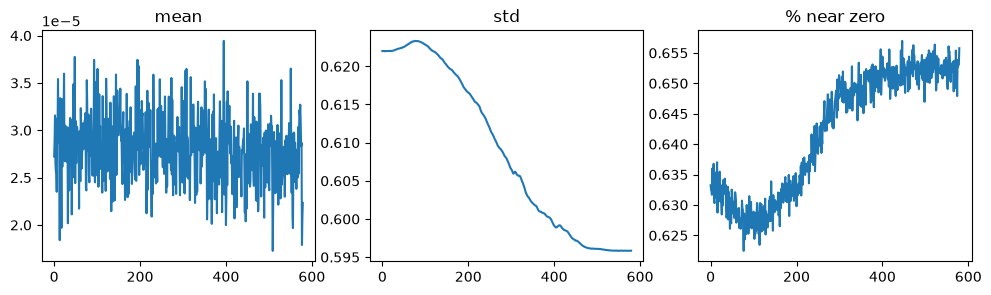

In [ ]:
act_stats = ActivationStats(with_hist=True)
learn = Learner(dls_fuku, FukuCNN(), loss_func=MSELossFlat(), metrics=R2Score(), cbs=act_stats)
learn.fit_one_cycle(20, lr_max=2e-3)
act_stats.plot_layer_stats(idx=0)

Not that compelling either!

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

You're right, still poor performance. Let's check the actual dimensions:

```python
x, y = dls_fuku.train.one_batch()
print("Input:", x.shape)
print("After backbone:", learn.model.backbone(x).shape)
```

With 3 pooling layers (stride=2): 657→328→164→82→1. That's still losing a lot of resolution.

Let's try a much simpler architecture - just 1 conv layer:

```python
class SimpleCNN(Module):
    def __init__(self, n_in=1, n_out=1):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv1d(n_in, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
        )
        self.head = nn.Sequential(nn.Dropout(0.1), nn.Linear(64, n_out))
    
    def forward(self, x): return self.head(self.backbone(x))
```

```python
act_stats = ActivationStats(with_hist=True)
learn = Learner(dls_fuku, SimpleCNN(), loss_func=MSELossFlat(), metrics=R2Score(), cbs=act_stats)
learn.fit_one_cycle(20, lr_max=1e-3)
act_stats.plot_layer_stats(idx=0)
```

<details class='token-usage-details' markdown='1'><summary>$0.0104</summary>

`total=65,554 | in=64,986 | out=568 | cached=96.1% | $0.0104 | qwen3p7-plus`

</details>


In [ ]:
x, y = dls_fuku.train.one_batch()
print("Input:", x.shape)
print("After backbone:", learn.model.backbone(x).shape)

Input: torch.Size([32, 1, 657])


After backbone: torch.Size([32, 128])


In [ ]:
class SimpleCNN(Module):
    def __init__(self, n_in=1, n_out=1):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv1d(n_in, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
        )
        self.head = nn.Sequential(nn.Dropout(0.1), nn.Linear(64, n_out))
    
    def forward(self, x): return self.head(self.backbone(x))

/app/data/.local/lib/python3.12/site-packages/fastai/callback/core.py:71: UserWarning: You are shadowing an attribute (modules) that exists in the learner. Use `self.learn.modules` to avoid this
  warn(f"You are shadowing an attribute ({name}) that exists in the learner. Use `self.learn.{name}` to avoid this")


epoch     train_loss  valid_loss  r2_score  time    


Epoch 1/20 : |----------------------------------------| 0.00% [0/29 00:00<?]

Epoch 1/20 : |█---------------------------------------| 3.45% [1/29 00:00<00:21]

Epoch 1/20 : |██--------------------------------------| 6.90% [2/29 00:00<00:12... 1.9999]

...

Epoch 20/20 : |█████████████████████████---------------| 62.50% [5/8 00:01<00:00... 0.1356]

Epoch 20/20 : |██████████████████████████████----------| 75.00% [6/8 00:01<00:00... 0.1356]

Epoch 20/20 : |███████████████████████████████████-----| 87.50% [7/8 00:01<00:00... 0.1356]

Epoch 20/20 : |████████████████████████████████████████| 100.00% [8/8 00:01<00:00... 0.1356]

19        0.135570    0.148170    -0.070157 00:05     


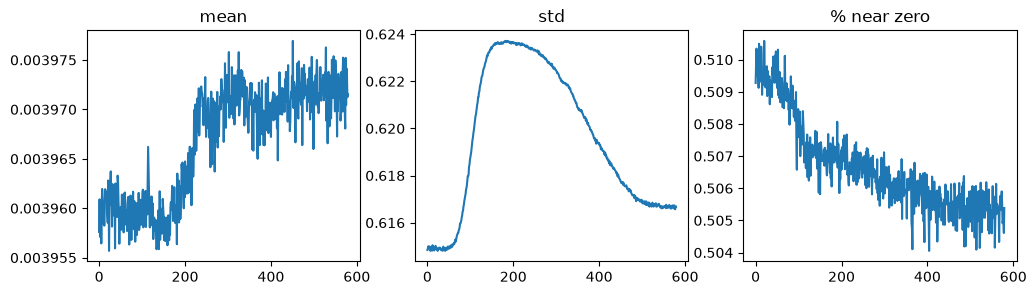

In [ ]:
act_stats = ActivationStats(with_hist=True)
learn = Learner(dls_fuku, SimpleCNN(), loss_func=MSELossFlat(), metrics=R2Score(), cbs=act_stats)
learn.fit_one_cycle(20, lr_max=1e-3)
act_stats.plot_layer_stats(idx=0)

The performance is poor but at least the %near zero look more as what's expected right?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Yes, exactly. For LeakyReLU with negative_slope=0.1, we expect roughly 50% of activations to be near zero (the negative half gets squashed). The 50-51% we see is healthy — much better than the 96.7% from before.

The activations are flowing properly now, but the model isn't learning the mapping well. Train loss decreases but valid loss plateaus at 0.148. Let's try a lower learning rate and more epochs:

```python
act_stats = ActivationStats(with_hist=True)
learn = Learner(dls_fuku, SimpleCNN(), loss_func=MSELossFlat(), metrics=R2Score(), cbs=act_stats)
learn.fit_one_cycle(50, lr_max=5e-4)
```

<details class='token-usage-details' markdown='1'><summary>$0.0413</summary>

`total=67,483 | in=67,044 | out=439 | cached=0.0% | $0.0413 | qwen3p7-plus`

</details>


In [ ]:
act_stats = ActivationStats(with_hist=True)
learn = Learner(dls_fuku, SimpleCNN(), loss_func=MSELossFlat(), metrics=R2Score(), cbs=act_stats)
learn.fit_one_cycle(50, lr_max=5e-4)